# Количественный анализ результативности интервенций

Чистовая версия notebook для воспроизводимого приложения к дипломной работе. В ноутбуке оставлены только загрузка данных, подготовка переменных, расчеты по уровням анализа, итоговые таблицы, графики и регрессионные модели.


## 1. Импорты и настройки

В этом блоке задаются пути, основные переменные, список целей, score-переменные, показатели поддержки и год разделения исторических периодов.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import combinations
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr, pearsonr, mannwhitneyu, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
except Exception:
    OrderedModel = None

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

MAIN_RESULTS_FILE = "Results_table-3.xlsx"
CONTEXT_FILE = "merged_dataset_improved.csv"
HUMANITARIAN_CRISIS_FILE = "Копия hum_crisis.xlsx"
ETHICS_FILE = "Копия ethics_copy.xlsx"
HISTORICAL_SPLIT_YEAR = 2008

GOAL_COLUMNS = [
    "military_counterrebels",
    "military_supportrebels",
    "military_supportgovernment",
    "military_countergovernment",
    "consequences_coercion",
    "consequences_humanitarian",
    "consequences_safezones",
    "consequences_refugees",
    "consequences_stabilization",
    "geopolitical_counternonstate",
    "geopolitical_position",
    "geopolitical_preemption",
]
MILITARY_GOAL_COLUMNS = [
    "military_counterrebels",
    "military_supportrebels",
    "military_supportgovernment",
    "military_countergovernment",
    "consequences_coercion",
]
HUMANITARIAN_GOAL_COLUMNS = [
    "consequences_humanitarian",
    "consequences_safezones",
    "consequences_refugees",
    "consequences_stabilization",
]
GEOPOLITICAL_GOAL_COLUMNS = [
    "geopolitical_counternonstate",
    "geopolitical_position",
    "geopolitical_preemption",
]
SCORE_COLUMNS = ["overall_score", "mil_score_t1", "hum_score_t2", "geo_score_t3"]
SUPPORT_COLUMNS = ["law_other", "law_other_mean", "law_other_support_mean"]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def find_file(name):
    candidates = [DATA_DIR / name, ROOT / name, Path(name)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Не найден файл {name}. Поместите его в data/ или в корневую папку проекта."
    )


def _norm_text(value):
    return re.sub(r"\s+", " ", str(value).replace("_", " ").replace("-", " ").lower()).strip()


def find_local_file_by_keywords(keyword_groups, suffixes=None):
    suffixes = {suffix.lower() for suffix in suffixes} if suffixes else None
    search_dirs = [DATA_DIR, ROOT]
    files = []
    for directory in search_dirs:
        if directory.exists():
            files.extend(path for path in directory.iterdir() if path.is_file())
    for keys in keyword_groups:
        keys = [_norm_text(key) for key in keys]
        for path in files:
            if suffixes and path.suffix.lower() not in suffixes:
                continue
            if all(key in _norm_text(path.stem) for key in keys):
                return path
    return None


def find_col_by_keywords(df_, keyword_sets, default=None):
    lowered = {column: _norm_text(column) for column in df_.columns}
    for keys in keyword_sets:
        keys = [_norm_text(key) for key in keys]
        for column, normalized in lowered.items():
            if all(key in normalized for key in keys):
                return column
    return default


def coerce_binary_series(series):
    out = series.copy()
    if out.dtype == object:
        out = out.astype(str).str.strip().str.lower().replace({
            "true": 1, "false": 0, "yes": 1, "no": 0, "да": 1, "нет": 0,
            "nan": np.nan, "none": np.nan, "": np.nan,
        })
    return pd.to_numeric(out, errors="coerce")


def score_summary(series, success_threshold=4):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "N": int(values.shape[0]),
        "mean": round(float(values.mean()), 3) if len(values) else np.nan,
        "median": round(float(values.median()), 3) if len(values) else np.nan,
        "std": round(float(values.std(ddof=1)), 3) if len(values) > 1 else np.nan,
        "min": round(float(values.min()), 3) if len(values) else np.nan,
        "max": round(float(values.max()), 3) if len(values) else np.nan,
        "success_share_ge4": round(float((values >= success_threshold).mean()), 3) if len(values) else np.nan,
    }


def safe_spearman(data, x, y, min_n=5):
    temp = data[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(temp) < min_n or temp[x].nunique() < 2 or temp[y].nunique() < 2:
        return len(temp), np.nan, np.nan
    corr, p_value = spearmanr(temp[x], temp[y])
    return len(temp), round(float(corr), 3), round(float(p_value), 4)


def model_table(model, model_name):
    return pd.DataFrame({
        "model": model_name,
        "variable": model.params.index,
        "coef": model.params.values,
        "p_value": model.pvalues.values,
    }).round({"coef": 4, "p_value": 4})


def save_current_figure(name):
    path = FIGURES_DIR / f"{name}.png"
    plt.gcf().savefig(path, dpi=300, bbox_inches="tight")
    return path


def save_table(df_, name):
    path = TABLES_DIR / f"{name}.csv"
    df_.to_csv(path, index=False)
    return path


## 2. Загрузка данных

Основная таблица загружается из `data/` или из корневой папки проекта. Абсолютные локальные пути не используются.


In [2]:
main_results_file = find_file(MAIN_RESULTS_FILE)
df = pd.read_excel(main_results_file)

rename_cols = {
    df.columns[0]: "i_dyad_id",
    df.columns[1]: "i_triple_id",
    "Кодифицированные цели интервенции": "coded_goals",

    "Изменение числа атак/боевых событий НВФ (T1)": "nonstate_attacks_t1",
    "Изменение числа потерь (военных/комбатантов) (T1)": "nonstate_combatant_casualties_t1",
    "Смена режима / падение правительства (T3)": "pol_regime_change_t3",
    "Изменение уровня демократии (T3)": "pol_democracy_change_t3",
    "Стабильность / уровень насилия (T3)": "pol_stability_t3",
    "Итоговый балл результативности (военный блок, T1)": "mil_score_t1",
    "Итоговый балл результативности (гуманитарный блок, T2)": "hum_score_t2",
    "Итоговый балл результативности (геополитический блок, T3)": "geo_score_t3",
    "Общий балл результативности интервенции": "overall_score",
    "Название конфликта на английском языке (альтернативные устоявшиеся названия даются в скобках)": "c_name_en",
    "Название конфликта на русском языке (альтернативные устоявшиеся названия даются в скобках)": "c_name_ru",
    "Референтный объект - страна (группа стран), куда осуществляется интервенция (на русском языке)": "refobject_ru",
    "Референтный объект - страна (группа стран), куда осуществляется интервенция (на английском языке)": "refobject_en",
    "Название операции по вмешательству на английском языке (альтернативные названия, в том числе устоявшиейся на других языках даются в скобках). Если несколько операций сменяли друг друга (без значительной смены состава и эгиды), их названия указываются через дефис.": "i_name_en",
    "Референтный субъект - государство, осуществлявшее вмешательство в рамках коалиции": "refsubject_ru",
    "Год начала конфликта. Если вмешательство осуществляется в несколько конфликтов одновременно (при невозможности рассматривать эти конфликты вместе), указываются даты начала самого раннего из этих конфликтов и даты окончания самого позднего.": "c_year_start",
    "Месяц начала конфликта": "c_month_start",
    "Год осуществления интервенции": "i_year_start",
    "Месяц осуществления интервенции (реальное размещение войск, если такая информация доступна, иначе - дата решения о проведении интервенции)": "i_month_start",
    "Год завершения активной фазы интервенции (заявление о завершении операции или соглашение о прекращении огня), ongoing если заявление не сделано по состоянию на 1 июня 2022": "i_year_end",
    "Месяц завершения активной фазы интервенции (заявление о завершении операции или соглашение о прекращении огня), ongoing если заявление не сделано по состоянию на 1 июня 2022": "i_month_end",
    "Стабилизация региона (T3)": "geo_regional_stabilization_t3",
    "Устранение угрозы / динамика событий угрозы (T3)": "geo_threat_t3",
    "Итоговый балл результативности (политический/долгосрочный блок, T3)": "pol_score_t3",
    "Итоговый балл международной легитимации (T3)": "int_score_t3",
}
df = df.rename(columns=rename_cols)

df = df[df["coded_goals"] != "coded_goals"].copy()
df["i_dyad_id"] = df["i_dyad_id"].astype(str).str.strip()
df["i_triple_id"] = df["i_triple_id"].astype(str).str.strip()
if "refsubject_ru" in df.columns:
    df["refsubject_ru_clean"] = df["refsubject_ru"].astype(str).str.strip()

goal_cols = [
    "military_counterrebels",
    "military_supportrebels",
    "military_supportgovernment",
    "military_countergovernment",
    "consequences_coercion",
    "consequences_humanitarian",
    "consequences_safezones",
    "consequences_refugees",
    "consequences_stabilization",
    "geopolitical_counternonstate",
    "geopolitical_position",
    "geopolitical_preemption",
]

military_goal_cols = [
    "military_counterrebels",
    "military_supportrebels",
    "military_supportgovernment",
    "military_countergovernment",
    "consequences_coercion",
]
humanitarian_goal_cols = [
    "consequences_humanitarian",
    "consequences_safezones",
    "consequences_refugees",
    "consequences_stabilization",
]
geopolitical_goal_cols = [
    "geopolitical_counternonstate",
    "geopolitical_position",
    "geopolitical_preemption",
]

scores = ["overall_score", "mil_score_t1", "hum_score_t2", "geo_score_t3"]
geo_indicator_cols = [c for c in ["geo_regional_stabilization_t3", "geo_threat_t3", "geo_score_t3"] if c in df.columns]
political_indicator_cols = [c for c in ["pol_regime_change_t3", "pol_democracy_change_t3", "pol_stability_t3", "pol_stabilization_t3"] if c in df.columns]


def clean_goals(x):
    if pd.isna(x):
        return []
    x = str(x).lower()
    x = x.replace("geopolitical_counernonstate", "geopolitical_counternonstate")
    return [part.strip() for part in x.split(",") if part.strip() and part.strip() != "coded_goals"]


df["goals_list"] = df["coded_goals"].apply(clean_goals)

for goal in goal_cols:
    df[goal] = df["goals_list"].apply(lambda xs: int(goal in xs))

for col in scores + geo_indicator_cols + political_indicator_cols + ["pol_score_t3", "int_score_t3", "nonstate_attacks_t1", "nonstate_combatant_casualties_t1"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "geo_regional_stabilization_t3" in df.columns:
    df["pol_stabilization_t3"] = df["geo_regional_stabilization_t3"]
if "pol_regime_change_t3" in df.columns:
    df["pol_regime_survival_t3"] = 1 - df["pol_regime_change_t3"]

SCORES_EXTENDED = [c for c in ["overall_score", "mil_score_t1", "hum_score_t2", "pol_score_t3", "geo_score_t3"] if c in df.columns]

df["military_goal"] = df[military_goal_cols].max(axis=1)
df["humanitarian_goal"] = df[humanitarian_goal_cols].max(axis=1)
df["geopolitical_goal"] = df[geopolitical_goal_cols].max(axis=1)

df["old_goal_based_pro_gov"] = df["military_supportgovernment"]
df["old_goal_based_anti_gov"] = df["military_countergovernment"]

for col in ["c_year_start", "c_month_start", "i_year_start", "i_month_start", "i_year_end", "i_month_end"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["conflict_start_month"] = df["c_year_start"] * 12 + df["c_month_start"]
df["intervention_start_month"] = df["i_year_start"] * 12 + df["i_month_start"]
df["intervention_end_month"] = df["i_year_end"] * 12 + df["i_month_end"]

df["delay_months"] = df["intervention_start_month"] - df["conflict_start_month"]
df["duration_years"] = (df["intervention_end_month"] - df["intervention_start_month"]) / 12
df["duration_years"] = pd.to_numeric(df["duration_years"], errors="coerce")
df["duration_sq"] = df["duration_years"] ** 2

df["period_2008"] = np.where(df["i_year_start"].le(HISTORICAL_SPLIT_YEAR), "До 2008", "После 2008")
df.loc[df["i_year_start"].isna(), "period_2008"] = np.nan

df["is_success"] = (df["overall_score"] >= 3).astype(int)
df["is_success_ge4"] = (df["overall_score"] >= 4).astype(int)


## 3. Подготовка переменных

В этом блоке объединяются данные о стороне вмешательства, гуманитарном кризисе и показателях поддержки; затем задаются русские подписи и функции визуализации.


In [3]:
side_file = find_local_file_by_keywords(
    [["i", "side", "intern"], ["iside"], ["side", "intern"], ["interns"], ["side"]],
    suffixes={".csv", ".xlsx", ".xls"}
)
if side_file is None:
    raise FileNotFoundError("Не удалось найти таблицу стороны вмешательства в рабочей папке")
side_raw = pd.read_csv(side_file) if side_file.suffix.lower() == ".csv" else pd.read_excel(side_file)
side_id_col = "i_dyad_id" if "i_dyad_id" in side_raw.columns else find_col_by_keywords(side_raw, [["i", "dyad", "id"], ["dyad", "id"], ["id"]])
side_value_col = "i_side_final" if "i_side_final" in side_raw.columns else find_col_by_keywords(side_raw, [["side", "final"], ["i", "side"], ["side"]])
if side_id_col is None or side_value_col is None:
    raise ValueError("Не удалось определить ID и сторону вмешательства")

side_prepared = side_raw.copy()
side_prepared["_side_id"] = side_prepared[side_id_col].astype(str).str.strip()
side_prepared["_side_code"] = pd.to_numeric(side_prepared[side_value_col], errors="coerce")
side_unique = side_prepared.drop_duplicates("_side_id", keep="first").copy()


def classify_intervention_side(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    numeric = pd.to_numeric(pd.Series([text]), errors="coerce").iloc[0]
    if pd.notna(numeric):
        return {3: "pro_government", 2: "neutral", 1: "pro_rebel"}.get(int(numeric), np.nan)
    if any(k in text for k in ["pro_government", "government", "правитель", "gov"]):
        return "pro_government"
    if any(k in text for k in ["neutral", "нейтр"]):
        return "neutral"
    if any(k in text for k in ["rebel", "anti", "повстан", "антиправ"]):
        return "pro_rebel"
    return np.nan

side_vars = side_unique[["_side_id", "_side_code"]].rename(columns={"_side_id": "i_dyad_id", "_side_code": "intervention_side_source_code"})
side_vars["intervention_side_final"] = side_vars["intervention_side_source_code"].apply(classify_intervention_side)
df = df.merge(side_vars, on="i_dyad_id", how="left")

case_context_cols = [c for c in ["i_dyad_id", "c_name_en", "c_name_ru", "refobject_ru", "i_name_en", "refsubject_ru"] if c in df.columns]

context_file = find_file(CONTEXT_FILE)
context_raw = pd.read_csv(context_file)
context_id_col = "i_dyad_id" if "i_dyad_id" in context_raw.columns else find_col_by_keywords(context_raw, [["i", "dyad", "id"], ["id"]])
if context_id_col is None:
    raise ValueError("Не удалось определить ID в контекстной таблице")

support_candidate_patterns = {
    "law_other": ["law_other"],
    "law_other_mean": ["law_other_mean"],
    "law_other_support_mean": ["law_other_support_mean", "support_mean"],
}


def choose_context_col(candidates):
    for c in candidates:
        if c in context_raw.columns:
            return c
    return None

support_source_cols = {std: choose_context_col(candidates) for std, candidates in support_candidate_patterns.items()}
missing_support = [k for k, v in support_source_cols.items() if v is None]
if missing_support:
    raise ValueError("Не найдены переменные поддержки: " + ", ".join(missing_support))


objective_index_col = next((c for c in ["objective_hum_crisis", "objective_humanitarian_crisis", "crisis_index_raw", "crisis_index_log"] if c in context_raw.columns), None)
if objective_index_col is None:
    raise ValueError("Не найден показатель объективного гуманитарного кризиса")

context_proxy_cols = [
    c for c in ["just_threat", "just_preemptive", "c_casualties_max", "log_casualties", "casualties_z", "matched_goal_data"]
    if c in context_raw.columns
]
context_keep = list(dict.fromkeys([context_id_col, objective_index_col] + list(support_source_cols.values()) + context_proxy_cols))
context_vars = context_raw[context_keep].drop_duplicates(context_id_col, keep="first").rename(columns={context_id_col: "i_dyad_id"})
context_vars = context_vars.rename(columns={objective_index_col: "objective_hum_crisis_index"})
df = df.merge(context_vars, on="i_dyad_id", how="left")

support_vars = ["law_other", "law_other_mean", "law_other_support_mean"]
SUPPORT_LABELS = {
    "law_other": "Международно-правовая поддержка",
    "law_other_mean": "Политическая поддержка со стороны великих держав",
    "law_other_support_mean": "Политическая поддержка",
}
for col in ["objective_hum_crisis_index"] + support_vars + context_proxy_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

objective_crisis_threshold = df["objective_hum_crisis_index"].median(skipna=True)
df["objective_hum_crisis"] = np.where(
    df["objective_hum_crisis_index"].notna(),
    (df["objective_hum_crisis_index"] >= objective_crisis_threshold).astype(int),
    np.nan,
)

hum_crisis_file = find_file(HUMANITARIAN_CRISIS_FILE)
hum_before_raw = pd.read_excel(hum_crisis_file, sheet_name="hum_before_case")
hum_id_col = "id диады (ТЕХНИЧЕСКОЕ)" if "id диады (ТЕХНИЧЕСКОЕ)" in hum_before_raw.columns else find_col_by_keywords(hum_before_raw, [["id", "диады"], ["dyad", "id"], ["id"]])
hum_crisis_col = "наличие гуманитарного кризиса (1/0)" if "наличие гуманитарного кризиса (1/0)" in hum_before_raw.columns else find_col_by_keywords(hum_before_raw, [["гуманитар", "криз"], ["humanitarian", "crisis"], ["crisis"]])
if hum_id_col is None or hum_crisis_col is None:
    raise ValueError("Не удалось определить переменную субъективного гуманитарного кризиса")

hum_before = hum_before_raw[[hum_id_col, hum_crisis_col]].copy()
hum_before = hum_before[hum_before[hum_id_col].astype(str).str.strip().ne("i_dyad_id")].copy()
hum_before["i_dyad_id"] = hum_before[hum_id_col].astype(str).str.strip()
hum_before["subjective_hum_crisis"] = coerce_binary_series(hum_before[hum_crisis_col])
hum_vars = hum_before[["i_dyad_id", "subjective_hum_crisis"]].drop_duplicates("i_dyad_id", keep="first")
df = df.merge(hum_vars, on="i_dyad_id", how="left")

df["any_hum_crisis"] = np.where(
    df[["subjective_hum_crisis", "objective_hum_crisis"]].notna().any(axis=1),
    df[["subjective_hum_crisis", "objective_hum_crisis"]].fillna(0).max(axis=1),
    np.nan,
)
df["both_hum_crises"] = np.where(
    df[["subjective_hum_crisis", "objective_hum_crisis"]].notna().all(axis=1),
    ((df["subjective_hum_crisis"].eq(1)) & (df["objective_hum_crisis"].eq(1))).astype(int),
    np.nan,
)
df["hum_crisis_group"] = np.select(
    [
        df["subjective_hum_crisis"].eq(1) & df["objective_hum_crisis"].eq(1),
        df["subjective_hum_crisis"].eq(1) & df["objective_hum_crisis"].ne(1),
        df["subjective_hum_crisis"].ne(1) & df["objective_hum_crisis"].eq(1),
        df["any_hum_crisis"].eq(0),
    ],
    ["оба типа кризиса", "только субъективный", "только объективный", "кризис не выявлен"],
    default=None,
)


In [4]:
GOAL_RU = {
    "military_counterrebels": "Военная: борьба с повстанцами",
    "military_supportrebels": "Военная: поддержка повстанцев",
    "military_supportgovernment": "Военная: поддержка правительства",
    "military_countergovernment": "Военная: давление на правительство",
    "consequences_coercion": "Военная: принуждение к миру",
    "consequences_humanitarian": "Гуманитарная: защита населения",
    "consequences_safezones": "Гуманитарная: безопасные зоны",
    "consequences_refugees": "Гуманитарная: беженцы",
    "consequences_stabilization": "Гуманитарная: стабилизация",
    "geopolitical_counternonstate": "Геополитическая: против негос. акторов",
    "geopolitical_position": "Геополитическая: усиление позиции",
    "geopolitical_preemption": "Геополитическая: предупреждение угрозы",
}
SCORE_RU = {
    "overall_score": "Общая результативность",
    "mil_score_t1": "Военная результативность",
    "hum_score_t2": "Гуманитарная результативность",
    "geo_score_t3": "Геополитическая результативность",
    "pol_score_t3": "Политическая результативность",
}
GEO_INDICATOR_RU = {
    "geo_regional_stabilization_t3": "Стабилизация региона (T3)",
    "geo_threat_t3": "Устранение угрозы (T3)",
    "geo_score_t3": "Геополитический итоговый score",
}
BLOCK_RU = {"military":"Военные цели", "humanitarian":"Гуманитарные цели", "geopolitical":"Геополитические цели"}
GOAL_BLOCK = {
    g: ("military" if (g.startswith("military") or g == "consequences_coercion") else "humanitarian" if g.startswith("consequences") else "geopolitical")
    for g in goal_cols
}
MILITARY_DIRECTIONAL_GOAL_GROUP = {
    "military_counterrebels": "pro_government",
    "military_supportgovernment": "pro_government",
    "military_supportrebels": "pro_rebel",
    "military_countergovernment": "pro_rebel",
}
BLOCK_COLORS = {"military":"#4C78A8", "humanitarian":"#59A14F", "geopolitical":"#F28E2B", "other":"#9D9D9D"}
SIDE_RU = {
    "pro_government": "Проправительственная",
    "neutral": "Нейтральная",
    "pro_rebel": "Антиправительственная/проповстанческая",
}
SIDE_COLORS = {"pro_government": "#4C78A8", "neutral": "#9D9D9D", "pro_rebel": "#E15759"}
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


def ru_goal(g):
    return GOAL_RU.get(g, g)


def add_goal_labels(tbl, goal_col="goal"):
    out = tbl.copy()
    if goal_col in out.columns:
        out["goal_ru"] = out[goal_col].map(ru_goal)
        out["goal_block"] = out[goal_col].map(GOAL_BLOCK)
        out["goal_block_ru"] = out["goal_block"].map(BLOCK_RU)
    return out


def block_legend(ax):
    handles = [Patch(facecolor=BLOCK_COLORS[k], label=v) for k, v in BLOCK_RU.items()]
    ax.legend(handles=handles, title="Блок целей", loc="best", fontsize=10, title_fontsize=11)


def plot_goal_bars(data, value_col, title, ylabel="Значение", goal_col="goal", n_col=None, top=None, figsize=(13, 7), horizontal=False):
    plot_df = add_goal_labels(data, goal_col=goal_col).copy()
    if top is not None:
        plot_df = plot_df.head(top)
    plot_df["label"] = plot_df[goal_col].map(ru_goal).fillna(plot_df[goal_col].astype(str))
    if n_col and n_col in plot_df.columns:
        plot_df["label"] = plot_df["label"] + "\nN=" + plot_df[n_col].fillna(0).astype(int).astype(str)
    if not horizontal and plot_df["label"].astype(str).str.len().max() > 32:
        horizontal = True
        figsize = (figsize[0], max(figsize[1], 0.42 * len(plot_df) + 2.5))
    colors = plot_df["goal_block"].map(BLOCK_COLORS).fillna(BLOCK_COLORS["other"])
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        ax.barh(plot_df["label"], plot_df[value_col], color=colors)
        ax.invert_yaxis()
        ax.set_xlabel(ylabel, fontsize=12)
    else:
        ax.bar(plot_df["label"], plot_df[value_col], color=colors)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)
    ax.set_title(title, fontsize=16, pad=12)
    ax.grid(axis="y" if not horizontal else "x", alpha=0.25)
    block_legend(ax)
    plt.tight_layout()
    return fig, ax


def plot_bar_with_n(data, x_col, y_col, n_col, title, ylabel="Средний балл", color="#59A14F", figsize=(10, 6), rotate=20, min_groups=1, horizontal=None):
    plot_df = data.dropna(subset=[y_col]).copy()
    if plot_df.empty or plot_df[n_col].sum() == 0 or len(plot_df) < min_groups:
        return None, None
    labels = plot_df[x_col].astype(str) + "\nN=" + plot_df[n_col].fillna(0).astype(int).astype(str)
    if horizontal is None:
        horizontal = labels.astype(str).str.len().max() > 26 or len(labels) > 7
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        ax.barh(labels, plot_df[y_col], color=color)
        ax.invert_yaxis()
        ax.set_xlabel(ylabel)
        ax.grid(axis="x", alpha=0.25)
    else:
        ax.bar(labels, plot_df[y_col], color=color)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", labelrotation=rotate)
        ax.grid(axis="y", alpha=0.25)
    ax.set_title(title, pad=12)
    plt.tight_layout()
    return fig, ax


def plot_boxplot_with_n(data, group_col, score_col, title, ylabel="Балл", min_n=3, color="#59A14F", figsize=(10, 6)):
    groups = []
    labels = []
    for group, subset in data.groupby(group_col, dropna=True):
        values = pd.to_numeric(subset[score_col], errors="coerce").dropna()
        if len(values) >= min_n:
            groups.append(values.values)
            labels.append(f"{group}\nN={len(values)}")
    if not groups:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(groups, labels=labels, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=20)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    return fig, ax


def plot_corr_heatmap(corr_df, row_col, col_col, value_col, n_col, title, figsize=(10, 5)):
    plot_df = corr_df.copy()
    if plot_df.empty:
        return None, None
    heat = plot_df.pivot(index=row_col, columns=col_col, values=value_col)
    n_heat = plot_df.pivot(index=row_col, columns=col_col, values=n_col)
    if heat.empty:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heat.values, aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=35, ha="right")
    ax.set_yticks(range(heat.shape[0]), heat.index)
    ax.set_title(title, pad=12)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.iloc[i, j]
            n = n_heat.iloc[i, j]
            label = "" if pd.isna(val) else f"{val:.2f}\nN={int(n)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="Spearman r")
    plt.tight_layout()
    return fig, ax

df["intervention_side_ru"] = df["intervention_side_final"].map(SIDE_RU).fillna("Не определено")
df["pro_gov"] = df["intervention_side_final"].eq("pro_government").astype(int)
df["anti_gov"] = df["intervention_side_final"].eq("pro_rebel").astype(int)
df["neutral"] = df["intervention_side_final"].eq("neutral").astype(int)
df["h1_orientation"] = df["intervention_side_ru"]
df_non_neutral = df[df["intervention_side_final"].isin(["pro_government", "pro_rebel"])].copy()


## 4. Проверка баланса выборки

Показываются только распределения, которые нужны для интерпретации дальнейших сравнений: стороны вмешательства, блоки целей, отдельные цели и периоды до/после 2008 года.


In [5]:
balance_side_df = (
    df.groupby(["intervention_side_final", "intervention_side_ru"], dropna=False)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)

balance_goal_type_df = pd.DataFrame([
    {"goal_type": "Военные цели", "N": int(df["military_goal"].sum())},
    {"goal_type": "Гуманитарные цели", "N": int(df["humanitarian_goal"].sum())},
    {"goal_type": "Геополитические цели", "N": int(df["geopolitical_goal"].sum())},
])

balance_goals_df = pd.DataFrame([
    {"goal": g, "goal_ru": ru_goal(g), "goal_block": BLOCK_RU[GOAL_BLOCK[g]], "N": int(df[g].sum())}
    for g in goal_cols
]).sort_values(["goal_block", "N"], ascending=[True, False]).reset_index(drop=True)

period_2008_balance_df = (
    df.groupby("period_2008", dropna=False)
    .size()
    .reset_index(name="N")
)

display(balance_side_df)
display(balance_goal_type_df)
display(balance_goals_df)
display(period_2008_balance_df)


side_period_balance_df = (
    df[df["intervention_side_final"].isin(["pro_government", "pro_rebel", "neutral"])]
    .groupby(["intervention_side_ru", "period_2008"], as_index=False)
    .size()
    .rename(columns={"size": "N"})
    .sort_values(["intervention_side_ru", "period_2008"])
)
side_period_balance_df


,intervention_side_final,intervention_side_ru,N
1,pro_government,Проправительственная,49
0,neutral,Нейтральная,31
2,pro_rebel,Антиправительственная/проповстанческая,21


,goal_type,N
0,Военные цели,80
1,Гуманитарные цели,78
2,Геополитические цели,62


,goal,goal_ru,goal_block,N
0,military_supportgovernment,Военная: поддержка правительства,Военные цели,44
1,military_counterrebels,Военная: борьба с повстанцами,Военные цели,21
2,consequences_coercion,Военная: принуждение к миру,Военные цели,20
3,military_countergovernment,Военная: давление на правительство,Военные цели,8
4,military_supportrebels,Военная: поддержка повстанцев,Военные цели,5
5,geopolitical_counternonstate,Геополитическая: против негос. акторов,Геополитические цели,36
6,geopolitical_position,Геополитическая: усиление позиции,Геополитические цели,35
7,geopolitical_preemption,Геополитическая: предупреждение угрозы,Геополитические цели,7
8,consequences_stabilization,Гуманитарная: стабилизация,Гуманитарные цели,69
9,consequences_humanitarian,Гуманитарная: защита населения,Гуманитарные цели,40


,period_2008,N
0,До 2008,65
1,После 2008,36


,intervention_side_ru,period_2008,N
0,Антиправительственная/проповстанческая,До 2008,16
1,Антиправительственная/проповстанческая,После 2008,5
2,Нейтральная,До 2008,23
3,Нейтральная,После 2008,8
4,Проправительственная,До 2008,26
5,Проправительственная,После 2008,23


## 5. Уровень 1: декларация целей и результативность

Проверяется, связана ли декларация целей с профильной результативностью. Отдельно сохраняется сравнение проправительственных и антиправительственных направлений.


In [6]:
h1_side_summary_rows = []
for side, subset in df.groupby("intervention_side_final", dropna=True):
    for score in scores:
        vals = pd.to_numeric(subset[score], errors="coerce").dropna()
        h1_side_summary_rows.append({
            "intervention_side_final": side,
            "intervention_side_ru": SIDE_RU.get(side, side),
            "score": score,
            "score_ru": SCORE_RU[score],
            "N": int(vals.shape[0]),
            "mean": round(vals.mean(), 3) if len(vals) else np.nan,
            "median": round(vals.median(), 3) if len(vals) else np.nan,
            "std": round(vals.std(ddof=1), 3) if len(vals) > 1 else np.nan,
            "success_share_ge4": round((vals >= 4).mean(), 3) if len(vals) else np.nan,
        })
h1_side_summary_df = pd.DataFrame(h1_side_summary_rows)

h1_side_diff_rows = []
pro = df[df["intervention_side_final"].eq("pro_government")]
anti = df[df["intervention_side_final"].eq("pro_rebel")]
for score in scores:
    a = pd.to_numeric(pro[score], errors="coerce").dropna()
    b = pd.to_numeric(anti[score], errors="coerce").dropna()
    p = mannwhitneyu(a, b, alternative="two-sided").pvalue if len(a) >= 5 and len(b) >= 5 else np.nan
    h1_side_diff_rows.append({
        "comparison": "pro_government_minus_pro_rebel",
        "score": score,
        "score_ru": SCORE_RU[score],
        "n_pro_government": len(a),
        "mean_pro_government": round(a.mean(), 3) if len(a) else np.nan,
        "n_pro_rebel": len(b),
        "mean_pro_rebel": round(b.mean(), 3) if len(b) else np.nan,
        "difference_of_means": round(a.mean() - b.mean(), 3) if len(a) and len(b) else np.nan,
        "p_value_mannwhitney": round(p, 4) if pd.notna(p) else np.nan,
    })
h1_side_diff_df = pd.DataFrame(h1_side_diff_rows)

corr_results = []
for side_binary, side_label in [("pro_gov", "проправительственная"), ("anti_gov", "антиправительственная/проповстанческая")]:
    for score in scores:
        temp = df_non_neutral[[side_binary, score]].dropna()
        if len(temp) < 5 or temp[side_binary].nunique() < 2:
            corr, p = np.nan, np.nan
        else:
            corr, p = spearmanr(temp[side_binary], temp[score])
        corr_results.append({
            "side_group": side_label,
            "score": SCORE_RU.get(score, score),
            "n": len(temp),
            "corr": round(corr, 3) if pd.notna(corr) else np.nan,
            "p_value": round(p, 4) if pd.notna(p) else np.nan
        })
h1_corr_df = pd.DataFrame(corr_results)

display(h1_side_summary_df)
display(h1_side_diff_df)
display(h1_corr_df)


,intervention_side_final,intervention_side_ru,score,score_ru,N,mean,median,std,success_share_ge4
0,neutral,Нейтральная,overall_score,Общая результативность,31,2.855,3.0,0.924,0.290
1,neutral,Нейтральная,mil_score_t1,Военная результативность,31,3.742,4.0,0.815,0.581
2,neutral,Нейтральная,hum_score_t2,Гуманитарная результативность,31,2.839,3.0,0.898,0.323
3,neutral,Нейтральная,geo_score_t3,Геополитическая результативность,31,2.774,2.0,1.334,0.323
4,pro_government,Проправительственная,overall_score,Общая результативность,49,2.898,3.0,0.777,0.245
5,pro_government,Проправительственная,mil_score_t1,Военная результативность,48,3.875,4.0,0.672,0.708
6,pro_government,Проправительственная,hum_score_t2,Гуманитарная результативность,49,2.857,3.0,0.736,0.184
7,pro_government,Проправительственная,geo_score_t3,Геополитическая результативность,49,2.449,2.0,1.370,0.245
8,pro_rebel,Антиправительственная/проповстанческая,overall_score,Общая результативность,21,2.738,2.0,0.970,0.333
9,pro_rebel,Антиправительственная/проповстанческая,mil_score_t1,Военная результативность,18,3.722,3.5,0.958,0.500


,comparison,score,score_ru,n_pro_government,mean_pro_government,n_pro_rebel,mean_pro_rebel,difference_of_means,p_value_mannwhitney
0,pro_government_minus_pro_rebel,overall_score,Общая результативность,49,2.898,21,2.738,0.160,0.3743
1,pro_government_minus_pro_rebel,mil_score_t1,Военная результативность,48,3.875,18,3.722,0.153,0.4613
2,pro_government_minus_pro_rebel,hum_score_t2,Гуманитарная результативность,49,2.857,21,2.905,-0.048,0.6995
3,pro_government_minus_pro_rebel,geo_score_t3,Геополитическая результативность,49,2.449,21,2.190,0.259,0.8879


,side_group,score,n,corr,p_value
0,проправительственная,Общая результативность,70,0.108,0.3745
1,проправительственная,Военная результативность,66,0.092,0.4608
2,проправительственная,Гуманитарная результативность,70,0.047,0.6975
3,проправительственная,Геополитическая результативность,70,-0.018,0.8833
4,антиправительственная/проповстанческая,Общая результативность,70,-0.108,0.3745
5,антиправительственная/проповстанческая,Военная результативность,66,-0.092,0.4608
6,антиправительственная/проповстанческая,Гуманитарная результативность,70,-0.047,0.6975
7,антиправительственная/проповстанческая,Геополитическая результативность,70,0.018,0.8833


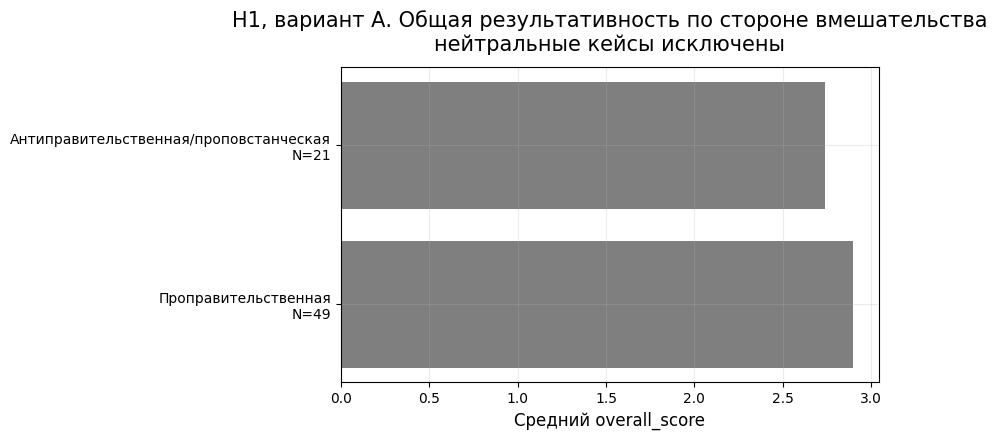

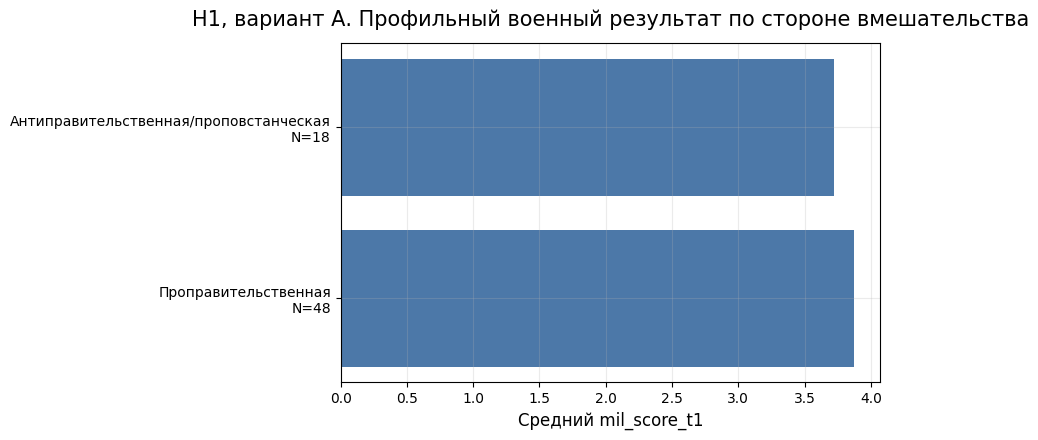

,goal,goal_ru,orientation,orientation_ru,profile_score,profile_score_ru,n_with_goal,mean_with_goal,n_without_goal,mean_without_goal,difference_of_means,spearman_corr,p_value_mannwhitney
2,military_supportrebels,Военная: поддержка повстанцев,pro_rebel,Антиправительственная/проповстанческая,mil_score_t1,Военная результативность,5,3.200,92,3.837,-0.637,-0.196,0.0563
3,military_countergovernment,Военная: давление на правительство,pro_rebel,Антиправительственная/проповстанческая,mil_score_t1,Военная результативность,6,3.667,91,3.813,-0.147,-0.053,0.6071
0,military_counterrebels,Военная: борьба с повстанцами,pro_government,Проправительственная,mil_score_t1,Военная результативность,20,3.800,77,3.805,-0.005,0.015,0.8859
1,military_supportgovernment,Военная: поддержка правительства,pro_government,Проправительственная,mil_score_t1,Военная результативность,44,3.841,53,3.774,0.067,0.032,0.7558


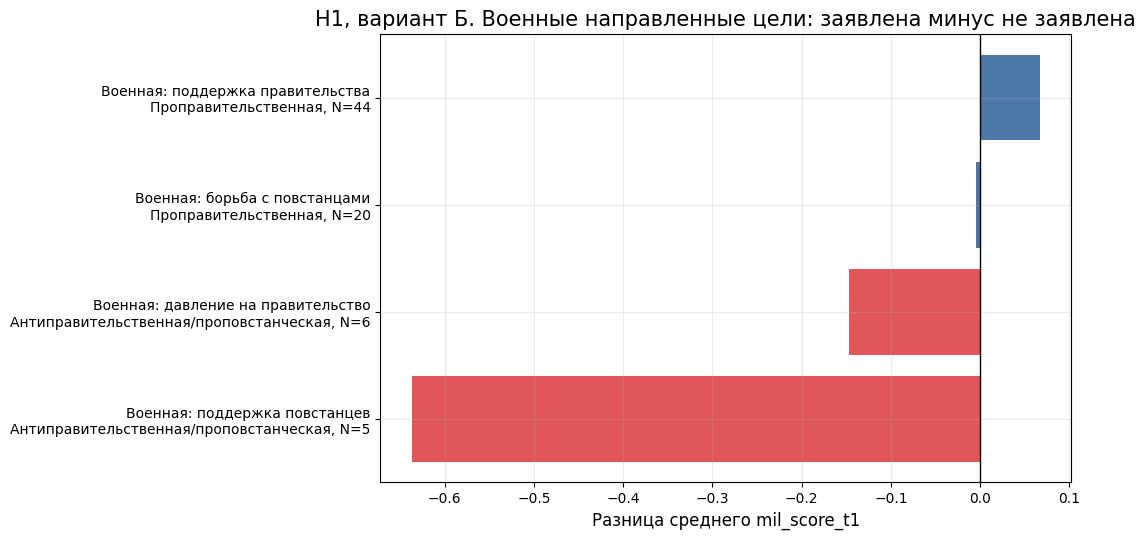

In [7]:
h1_side_overall_plot = h1_side_summary_df[
    h1_side_summary_df["intervention_side_final"].isin(["pro_government", "pro_rebel"])
    & h1_side_summary_df["score"].eq("overall_score")
].copy().sort_values("mean")
plot_bar_with_n(
    h1_side_overall_plot,
    x_col="intervention_side_ru", y_col="mean", n_col="N",
    title="H1, вариант А. Общая результативность по стороне вмешательства\nнейтральные кейсы исключены",
    ylabel="Средний overall_score", color="#7F7F7F", figsize=(9, 4.5), horizontal=True
)
save_current_figure("figure_11")
plt.show()

h1_side_profile_plot = h1_side_summary_df[
    h1_side_summary_df["intervention_side_final"].isin(["pro_government", "pro_rebel"])
    & h1_side_summary_df["score"].eq("mil_score_t1")
].copy().sort_values("mean")
plot_bar_with_n(
    h1_side_profile_plot,
    x_col="intervention_side_ru", y_col="mean", n_col="N",
    title="H1, вариант А. Профильный военный результат по стороне вмешательства",
    ylabel="Средний mil_score_t1", color=BLOCK_COLORS["military"], figsize=(9, 4.5), horizontal=True
)
save_current_figure("figure_12")
plt.show()

h1_military_directional_rows = []
for goal, orientation in MILITARY_DIRECTIONAL_GOAL_GROUP.items():
    with_goal = pd.to_numeric(df.loc[df[goal].eq(1), "mil_score_t1"], errors="coerce").dropna()
    without_goal = pd.to_numeric(df.loc[df[goal].eq(0), "mil_score_t1"], errors="coerce").dropna()
    if len(with_goal) >= 5 and len(without_goal) >= 5:
        p = mannwhitneyu(with_goal, without_goal, alternative="two-sided").pvalue
    else:
        p = np.nan
    temp = df[[goal, "mil_score_t1"]].dropna()
    corr, corr_p = (spearmanr(temp[goal], temp["mil_score_t1"]) if temp[goal].nunique() > 1 and len(temp) >= 5 else (np.nan, np.nan))
    h1_military_directional_rows.append({
        "goal": goal,
        "goal_ru": ru_goal(goal),
        "orientation": orientation,
        "orientation_ru": SIDE_RU[orientation],
        "profile_score": "mil_score_t1",
        "profile_score_ru": SCORE_RU["mil_score_t1"],
        "n_with_goal": len(with_goal),
        "mean_with_goal": round(with_goal.mean(), 3) if len(with_goal) else np.nan,
        "n_without_goal": len(without_goal),
        "mean_without_goal": round(without_goal.mean(), 3) if len(without_goal) else np.nan,
        "difference_of_means": round(with_goal.mean() - without_goal.mean(), 3) if len(with_goal) and len(without_goal) else np.nan,
        "spearman_corr": round(corr, 3) if pd.notna(corr) else np.nan,
        "p_value_mannwhitney": round(p, 4) if pd.notna(p) else np.nan,
    })
h1_military_directional_goals_df = pd.DataFrame(h1_military_directional_rows).sort_values("difference_of_means")
display(h1_military_directional_goals_df)

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df = h1_military_directional_goals_df.copy()
labels = plot_df["goal_ru"] + "\n" + plot_df["orientation_ru"] + ", N=" + plot_df["n_with_goal"].astype(str)
colors = plot_df["orientation"].map({"pro_government": SIDE_COLORS["pro_government"], "pro_rebel": SIDE_COLORS["pro_rebel"]})
ax.barh(labels, plot_df["difference_of_means"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("H1, вариант Б. Военные направленные цели: заявлена минус не заявлена")
ax.set_xlabel("Разница среднего mil_score_t1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_current_figure("figure_13")
plt.show()


In [8]:
goal_to_score = {
    "military_counterrebels": "mil_score_t1",
    "military_supportrebels": "mil_score_t1",
    "military_supportgovernment": "mil_score_t1",
    "military_countergovernment": "mil_score_t1",
    "consequences_coercion": "mil_score_t1",
    "consequences_humanitarian": "hum_score_t2",
    "consequences_safezones": "hum_score_t2",
    "consequences_refugees": "hum_score_t2",
    "consequences_stabilization": "hum_score_t2",
    "geopolitical_counternonstate": "geo_score_t3",
    "geopolitical_position": "geo_score_t3",
    "geopolitical_preemption": "geo_score_t3",
}

goal_results = []

for goal, score in goal_to_score.items():
    with_goal = df.loc[df[goal] == 1, score].dropna()
    without_goal = df.loc[df[goal] == 0, score].dropna()
    if len(with_goal) >= 5 and len(without_goal) >= 5:
        stat, p = mannwhitneyu(with_goal, without_goal, alternative="two-sided")
    else:
        p = np.nan
    goal_results.append({
        "goal": goal,
        "goal_ru": ru_goal(goal),
        "goal_block": GOAL_BLOCK[goal],
        "goal_block_ru": BLOCK_RU[GOAL_BLOCK[goal]],
        "profile_score": SCORE_RU[score],
        "n_with_goal": len(with_goal),
        "mean_with_goal": round(with_goal.mean(), 2),
        "n_without_goal": len(without_goal),
        "mean_without_goal": round(without_goal.mean(), 2),
        "diff": round(with_goal.mean() - without_goal.mean(), 2),
        "median_score": round(with_goal.median(), 2),
        "p_value": round(p, 4) if pd.notna(p) else np.nan,
        "significant": bool(p < 0.05) if pd.notna(p) else False,
    })

specific_goal_df = pd.DataFrame(goal_results).sort_values("mean_with_goal", ascending=False).reset_index(drop=True)

specific_goal_df["norm_score"] = (
    (specific_goal_df["mean_with_goal"] - specific_goal_df["mean_with_goal"].min()) /
    (specific_goal_df["mean_with_goal"].max() - specific_goal_df["mean_with_goal"].min())
)

specific_goal_df["category"] = pd.cut(
    specific_goal_df["norm_score"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["низкая", "средняя", "высокая"]
)

specific_goal_df["category_strict"] = specific_goal_df.apply(
    lambda x: "высокая" if (x["norm_score"] >= 0.66 and x["significant"])
    else ("средняя" if x["norm_score"] >= 0.33 else "низкая"),
    axis=1
)

goals_df = specific_goal_df.rename(columns={"mean_with_goal": "mean_score", "n_with_goal": "n"})

specific_goal_df[["goal", "goal_ru", "goal_block_ru", "profile_score", "n_with_goal", "mean_with_goal", "mean_without_goal", "diff", "p_value", "category_strict"]]


,goal,goal_ru,goal_block_ru,profile_score,n_with_goal,mean_with_goal,mean_without_goal,diff,p_value,category_strict
0,military_supportgovernment,Военная: поддержка правительства,Военные цели,Военная результативность,44,3.84,3.77,0.07,0.7558,средняя
1,military_counterrebels,Военная: борьба с повстанцами,Военные цели,Военная результативность,20,3.80,3.81,-0.01,0.8859,средняя
2,consequences_coercion,Военная: принуждение к миру,Военные цели,Военная результативность,18,3.78,3.81,-0.03,0.8931,средняя
3,military_countergovernment,Военная: давление на правительство,Военные цели,Военная результативность,6,3.67,3.81,-0.15,0.6071,средняя
4,consequences_safezones,Гуманитарная: безопасные зоны,Гуманитарные цели,Гуманитарная результативность,6,3.67,2.81,0.86,0.0173,высокая
5,military_supportrebels,Военная: поддержка повстанцев,Военные цели,Военная результативность,5,3.20,3.84,-0.64,0.0563,средняя
6,consequences_refugees,Гуманитарная: беженцы,Гуманитарные цели,Гуманитарная результативность,5,3.20,2.84,0.36,0.3449,средняя
7,consequences_humanitarian,Гуманитарная: защита населения,Гуманитарные цели,Гуманитарная результативность,40,3.10,2.70,0.40,0.0533,средняя
8,consequences_stabilization,Гуманитарная: стабилизация,Гуманитарные цели,Гуманитарная результативность,69,3.01,2.53,0.48,0.0036,средняя
9,geopolitical_counternonstate,Геополитическая: против негос. акторов,Геополитические цели,Геополитическая результативность,36,2.31,2.60,-0.29,0.3575,низкая


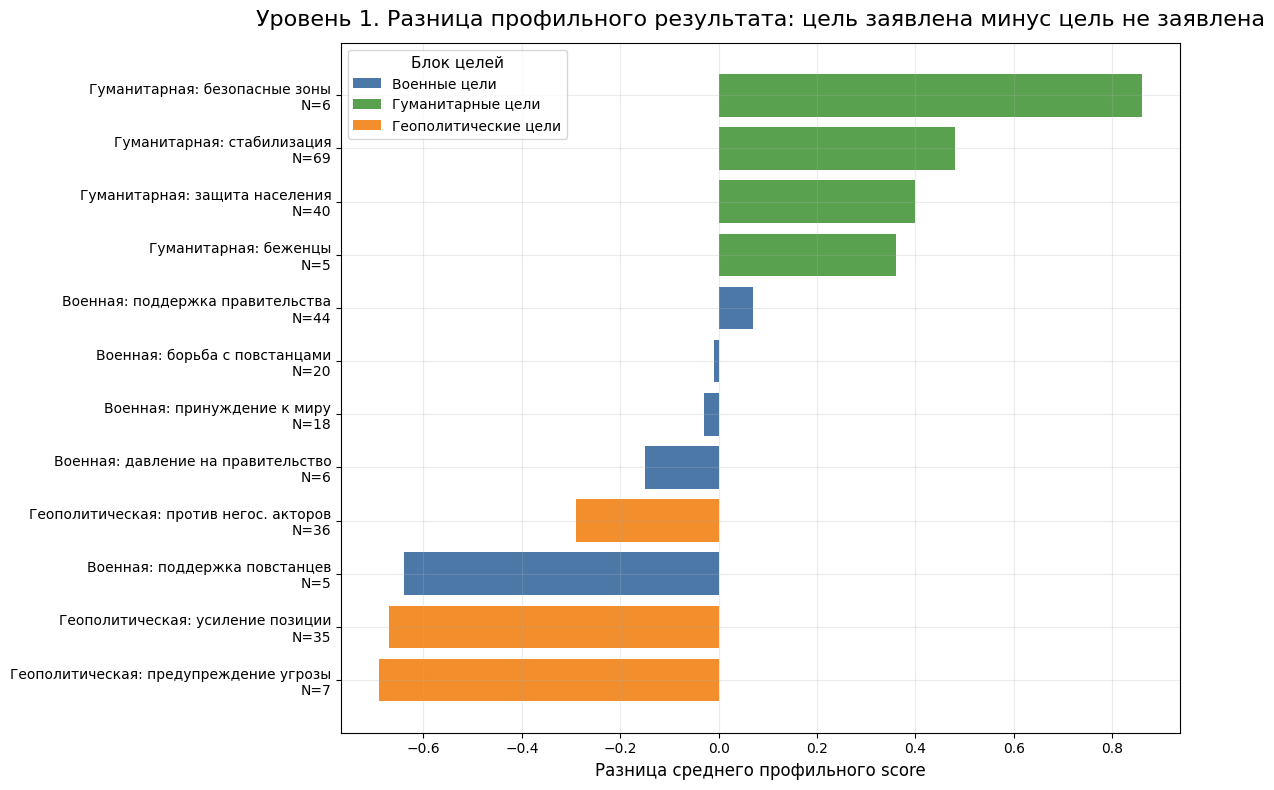

In [9]:
plot_goal_bars(
    specific_goal_df.sort_values("diff", ascending=False),
    value_col="diff",
    title="Уровень 1. Разница профильного результата: цель заявлена минус цель не заявлена",
    ylabel="Разница среднего профильного score",
    n_col="n_with_goal",
    horizontal=True,
    figsize=(12, 8)
)
save_current_figure("figure_14")
plt.show()


In [10]:
cross_results = []

for goal, profile_score in goal_to_score.items():
    for score in ["mil_score_t1", "hum_score_t2", "geo_score_t3"]:
        if score == profile_score:
            continue
        with_goal = df.loc[df[goal] == 1, score].dropna()
        without_goal = df.loc[df[goal] == 0, score].dropna()
        if len(with_goal) >= 5 and len(without_goal) >= 5:
            stat, p = mannwhitneyu(with_goal, without_goal, alternative="two-sided")
            cross_results.append({
                "goal": goal,
                "affected_score": score,
                "mean_with_goal": round(with_goal.mean(), 2),
                "mean_without_goal": round(without_goal.mean(), 2),
                "diff": round(with_goal.mean() - without_goal.mean(), 2),
                "p_value": round(p, 4),
            })

cross_df = pd.DataFrame(cross_results).sort_values("diff", ascending=False).reset_index(drop=True)
cross_df


,goal,affected_score,mean_with_goal,mean_without_goal,diff,p_value
0,consequences_stabilization,geo_score_t3,2.75,1.94,0.82,0.0037
1,consequences_refugees,geo_score_t3,3.00,2.47,0.53,0.3076
2,consequences_coercion,geo_score_t3,2.90,2.40,0.50,0.0810
3,military_supportgovernment,geo_score_t3,2.73,2.32,0.41,0.2471
4,consequences_safezones,geo_score_t3,2.83,2.47,0.36,0.5289
5,consequences_humanitarian,geo_score_t3,2.70,2.36,0.34,0.2588
6,consequences_safezones,mil_score_t1,4.00,3.79,0.21,0.5683
7,geopolitical_preemption,mil_score_t1,4.00,3.79,0.21,0.5683
8,consequences_refugees,mil_score_t1,4.00,3.79,0.21,0.5458
9,consequences_coercion,hum_score_t2,3.00,2.83,0.17,0.5278


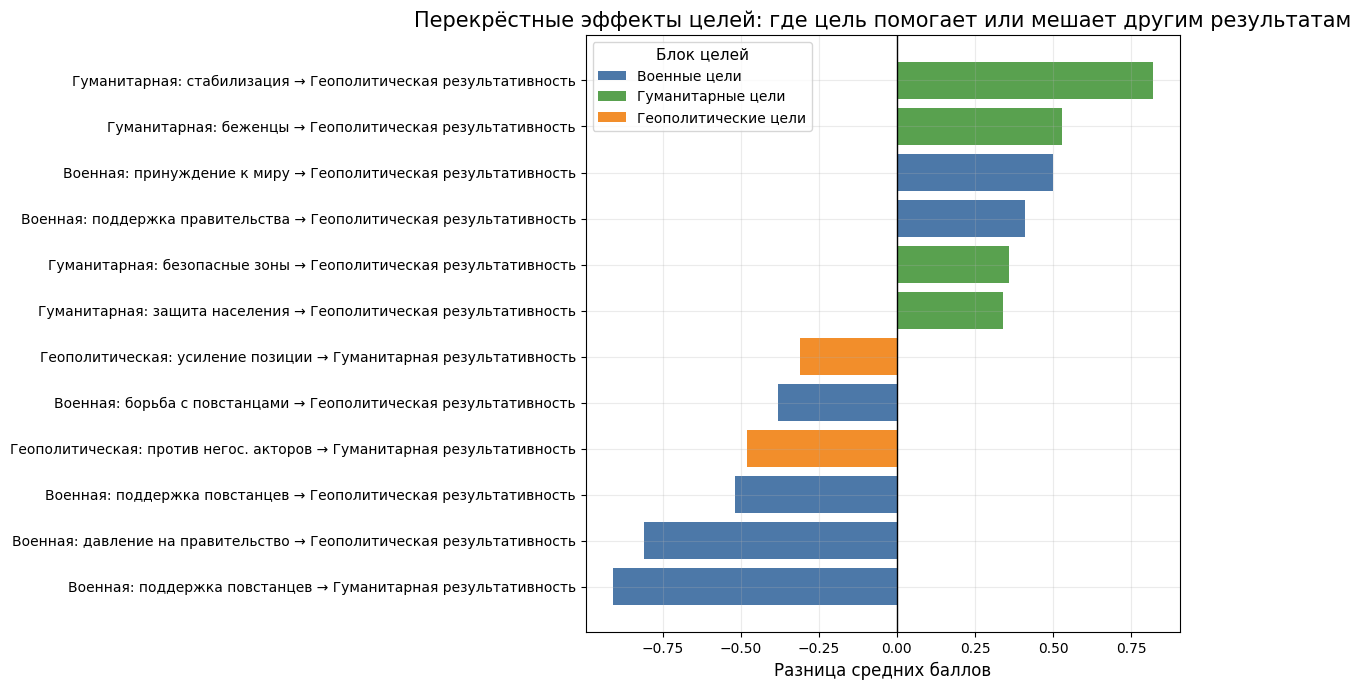

In [11]:
cross_plot = add_goal_labels(cross_df.copy(), "goal")
cross_plot["score_ru"] = cross_plot["affected_score"].map(SCORE_RU)
cross_plot["label"] = cross_plot["goal_ru"] + " → " + cross_plot["score_ru"]
cross_top = pd.concat([cross_plot.nsmallest(6, "diff"), cross_plot.nlargest(6, "diff")]).drop_duplicates().sort_values("diff")
fig, ax = plt.subplots(figsize=(12, 7))
colors = cross_top["goal_block"].map(BLOCK_COLORS)
ax.barh(cross_top["label"], cross_top["diff"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Перекрёстные эффекты целей: где цель помогает или мешает другим результатам", fontsize=15)
ax.set_xlabel("Разница средних баллов", fontsize=12)
block_legend(ax)
plt.tight_layout()
save_current_figure("figure_15")
plt.show()


## 6. Уровень 2: латентный успех и незаявленные цели

Этот уровень сравнивает заявленные и незаявленные цели: где декларация сопровождается профильным успехом, а где результат достигается без декларации цели.


In [12]:
empty_promises = []

for goal in goal_cols:
    temp = df[df[goal] == 1]
    empty_promises.append({
        "goal": goal,
        "empty_promise_rate": round((temp["overall_score"] < 3).mean(), 2),
        "n": len(temp)
    })

empty_df = pd.DataFrame(empty_promises).sort_values("empty_promise_rate", ascending=True).reset_index(drop=True)
empty_df


,goal,empty_promise_rate,n
0,consequences_safezones,0.17,6
1,consequences_refugees,0.20,5
2,consequences_stabilization,0.32,69
3,consequences_humanitarian,0.38,40
4,military_supportgovernment,0.41,44
5,military_counterrebels,0.48,21
6,consequences_coercion,0.50,20
7,geopolitical_counternonstate,0.53,36
8,geopolitical_position,0.60,35
9,military_countergovernment,0.62,8


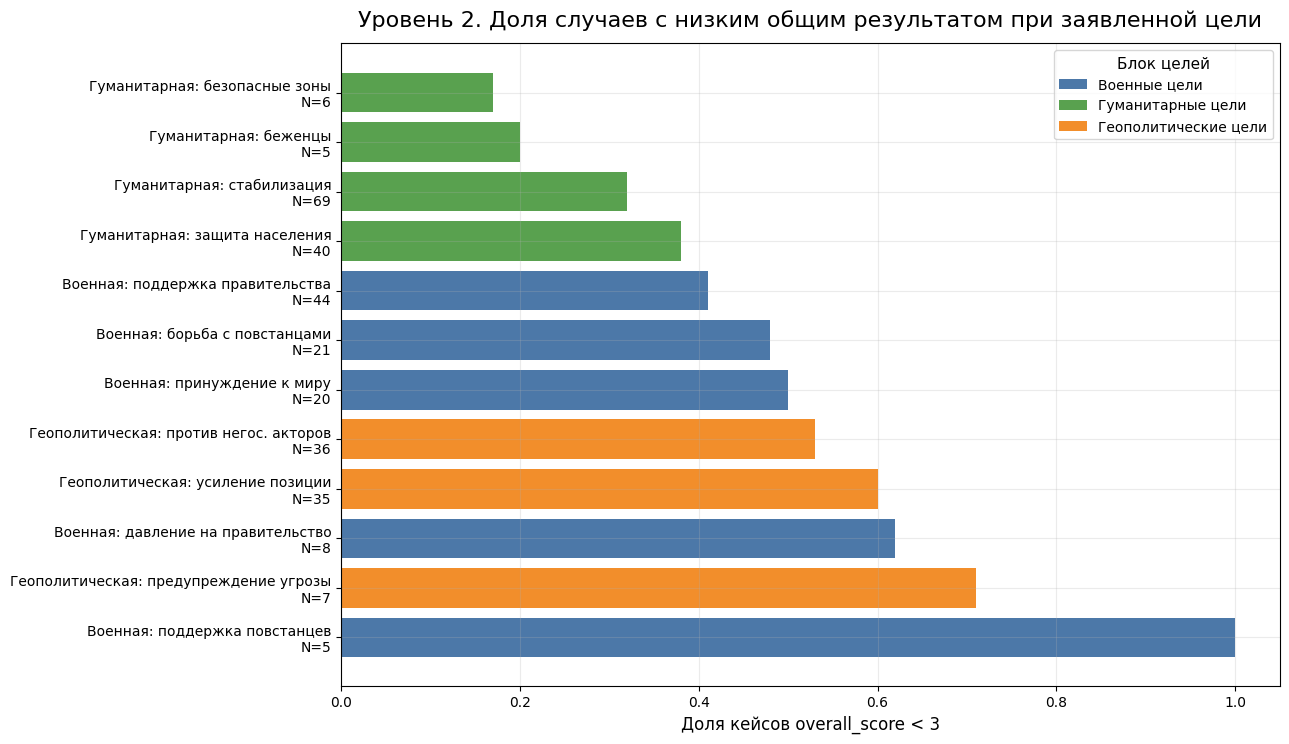

In [13]:
plot_goal_bars(
    empty_df,
    value_col="empty_promise_rate",
    title="Уровень 2. Доля случаев с низким общим результатом при заявленной цели",
    ylabel="Доля кейсов overall_score < 3",
    n_col="n"
)
save_current_figure("figure_16")
plt.show()


In [14]:
latent_success = []

for goal in goal_cols:
    temp = df[df[goal] == 0]
    latent_success.append({
        "goal": goal,
        "latent_success_rate": round((temp["overall_score"] >= 3).mean(), 2)
    })

latent_df = pd.DataFrame(latent_success).sort_values("latent_success_rate", ascending=False).reset_index(drop=True)
latent_df


,goal,latent_success_rate
0,geopolitical_position,0.64
1,geopolitical_counternonstate,0.60
2,military_supportrebels,0.58
3,military_countergovernment,0.57
4,consequences_coercion,0.57
5,geopolitical_preemption,0.57
6,military_counterrebels,0.56
7,consequences_safezones,0.54
8,consequences_refugees,0.54
9,military_supportgovernment,0.53


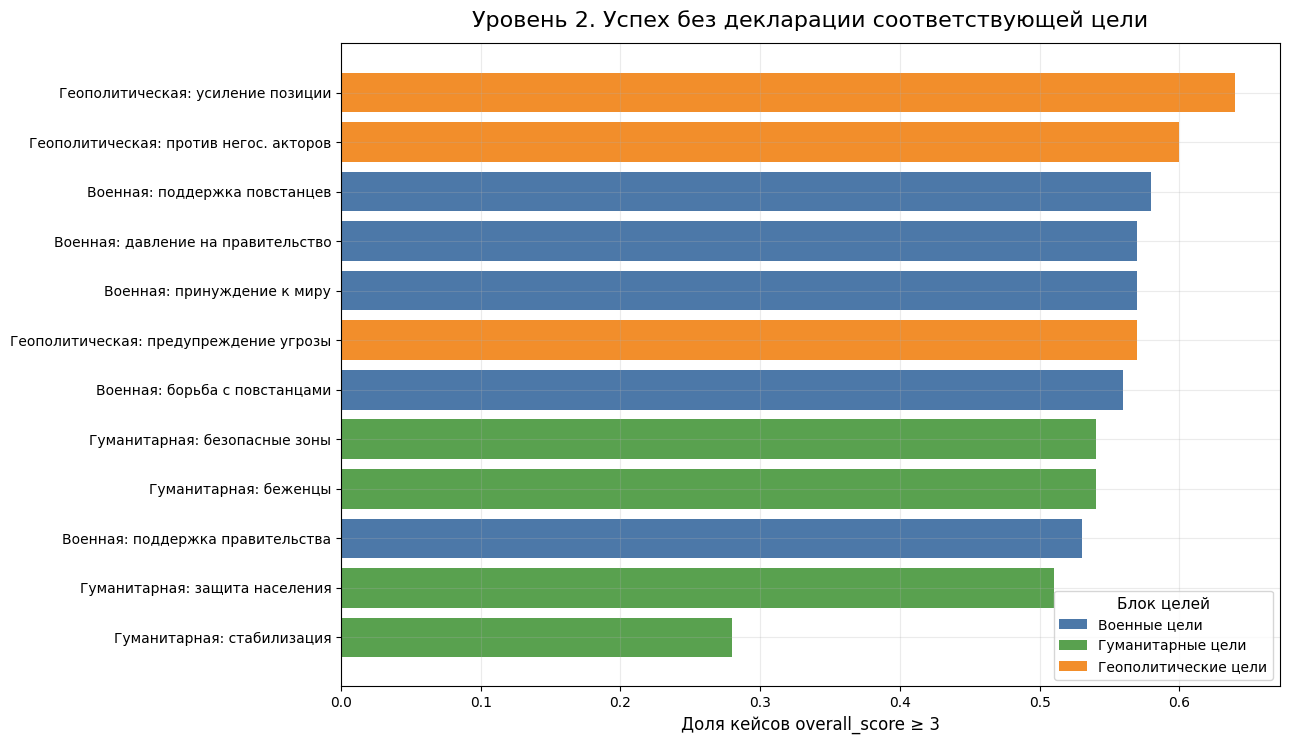

In [15]:
latent_plot = add_goal_labels(latent_df.copy())
plot_goal_bars(
    latent_plot.sort_values("latent_success_rate", ascending=False),
    value_col="latent_success_rate",
    title="Уровень 2. Успех без декларации соответствующей цели",
    ylabel="Доля кейсов overall_score ≥ 3"
)
save_current_figure("figure_17")
plt.show()


,block,block_ru,intervention_side_final,intervention_side_ru,profile_score,profile_score_ru,n_declared,mean_declared,n_undeclared,mean_undeclared,difference_declared_minus_undeclared,latent_success_share_undeclared_ge4
0,humanitarian,Гуманитарный блок,pro_government,Проправительственная,hum_score_t2,Гуманитарная результативность,37,2.946,12,2.583,0.363,0.583
1,humanitarian,Гуманитарный блок,pro_rebel,Антиправительственная/проповстанческая,hum_score_t2,Гуманитарная результативность,16,3.062,5,2.400,0.663,0.200
2,geopolitical,Геополитический блок,pro_government,Проправительственная,geo_score_t3,Геополитическая результативность,30,2.333,19,2.632,-0.298,0.316
3,geopolitical,Геополитический блок,pro_rebel,Антиправительственная/проповстанческая,geo_score_t3,Геополитическая результативность,16,2.125,5,2.400,-0.275,0.200


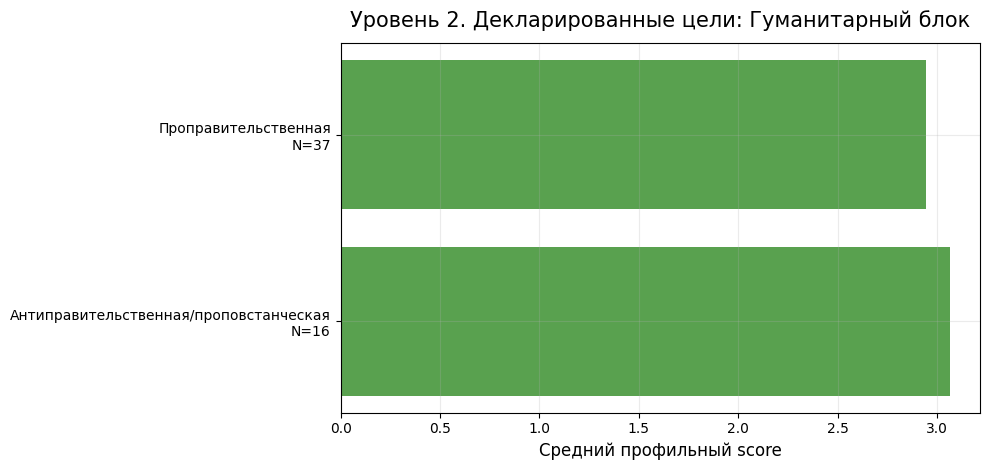

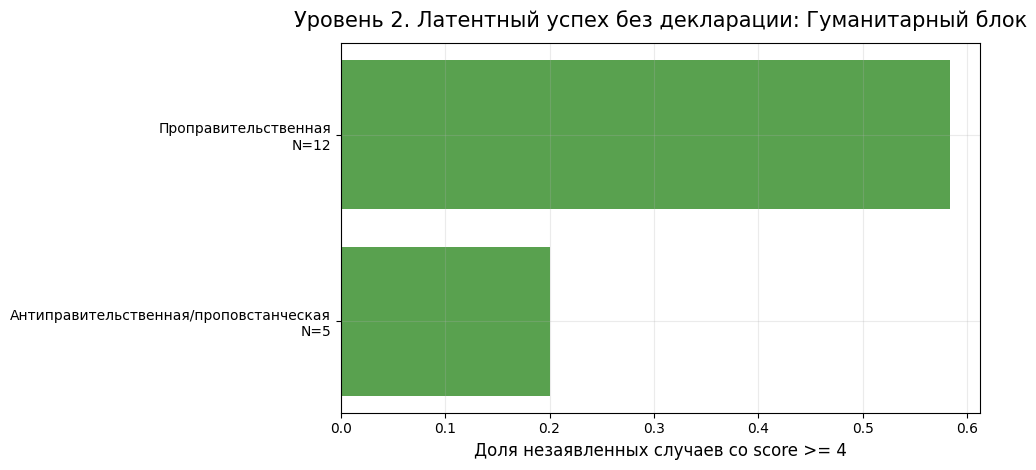

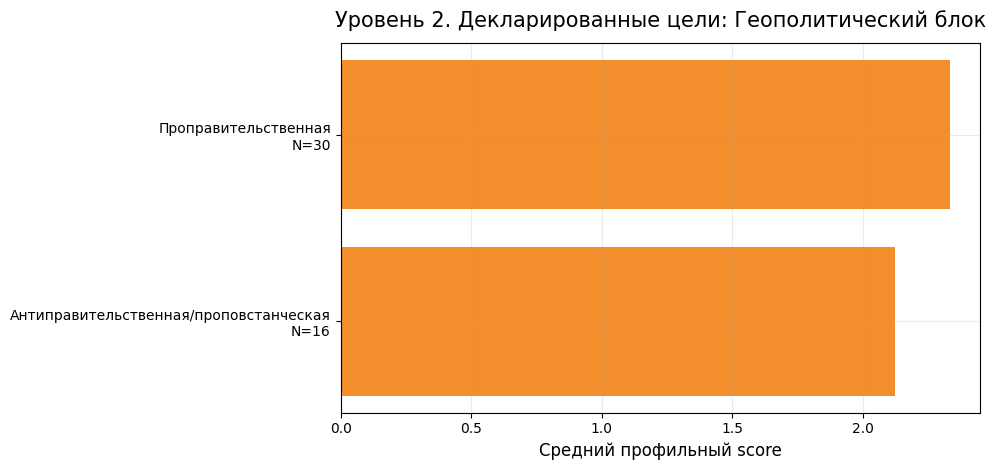

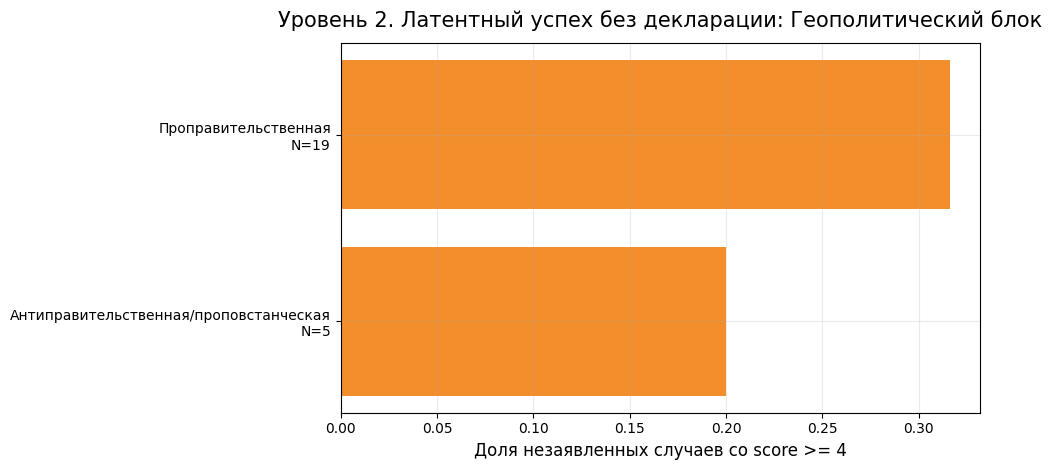

In [16]:
h2_side_rows = []
for block_key, block_label, goal_flag, score_col in [
    ("humanitarian", "Гуманитарный блок", "humanitarian_goal", "hum_score_t2"),
    ("geopolitical", "Геополитический блок", "geopolitical_goal", "geo_score_t3"),
]:
    for side in ["pro_government", "pro_rebel"]:
        subset = df[df["intervention_side_final"].eq(side)].copy()
        declared = pd.to_numeric(subset.loc[subset[goal_flag].eq(1), score_col], errors="coerce").dropna()
        undeclared = pd.to_numeric(subset.loc[subset[goal_flag].eq(0), score_col], errors="coerce").dropna()
        latent_success = (undeclared >= 3).mean() if len(undeclared) else np.nan
        h2_side_rows.append({
            "block": block_key,
            "block_ru": block_label,
            "intervention_side_final": side,
            "intervention_side_ru": SIDE_RU[side],
            "profile_score": score_col,
            "profile_score_ru": SCORE_RU[score_col],
            "n_declared": len(declared),
            "mean_declared": round(declared.mean(), 3) if len(declared) else np.nan,
            "n_undeclared": len(undeclared),
            "mean_undeclared": round(undeclared.mean(), 3) if len(undeclared) else np.nan,
            "difference_declared_minus_undeclared": round(declared.mean() - undeclared.mean(), 3) if len(declared) and len(undeclared) else np.nan,
            "latent_success_share_undeclared_ge4": round(latent_success, 3) if pd.notna(latent_success) else np.nan,
        })
h2_latent_by_side_df = pd.DataFrame(h2_side_rows)
display(h2_latent_by_side_df)

for block_key, color in [("humanitarian", BLOCK_COLORS["humanitarian"]), ("geopolitical", BLOCK_COLORS["geopolitical"] )]:
    plot_df = h2_latent_by_side_df[h2_latent_by_side_df["block"].eq(block_key)].copy()
    plot_bar_with_n(
        plot_df,
        x_col="intervention_side_ru", y_col="mean_declared", n_col="n_declared",
        title=f"Уровень 2. Декларированные цели: {plot_df['block_ru'].iloc[0]}",
        ylabel="Средний профильный score", color=color, figsize=(10, 4.8), horizontal=True
    )
    save_current_figure("figure_18")
    plt.show()
    plot_bar_with_n(
        plot_df,
        x_col="intervention_side_ru", y_col="latent_success_share_undeclared_ge4", n_col="n_undeclared",
        title=f"Уровень 2. Латентный успех без декларации: {plot_df['block_ru'].iloc[0]}",
        ylabel="Доля незаявленных случаев со score >= 4", color=color, figsize=(10, 4.8), horizontal=True
    )
    save_current_figure("figure_19")
    plt.show()


In [17]:
model_level2 = smf.logit(
    "is_success ~ military_goal + humanitarian_goal + geopolitical_goal + duration_years",
    data=df
).fit(disp=False)

level2_logit = pd.DataFrame({
    "variable": model_level2.params.index,
    "coef": model_level2.params.values,
    "odds_ratio": np.exp(model_level2.params.values),
    "p_value": model_level2.pvalues.values
}).round({"coef": 4, "odds_ratio": 3, "p_value": 4})

level2_logit


,variable,coef,odds_ratio,p_value
0,Intercept,0.1885,1.207,0.8433
1,military_goal,-0.7551,0.470,0.2183
2,humanitarian_goal,1.1794,3.253,0.0700
3,geopolitical_goal,-0.6887,0.502,0.1877
4,duration_years,0.0648,1.067,0.2897


In [18]:
h2_declared_vs_absent = []
for goal, profile_score in goal_to_score.items():
    a = df.loc[df[goal].eq(1), profile_score].dropna()
    b = df.loc[df[goal].eq(0), profile_score].dropna()
    if len(a) >= 5 and len(b) >= 5:
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
    else:
        p = np.nan
    h2_declared_vs_absent.append({
        "goal": goal, "goal_ru": ru_goal(goal), "goal_block_ru": BLOCK_RU[GOAL_BLOCK[goal]],
        "profile_score": SCORE_RU[profile_score], "n_goal_declared": len(a), "n_goal_absent": len(b),
        "mean_declared": round(a.mean(), 3), "mean_absent": round(b.mean(), 3),
        "added_value_declared": round(a.mean() - b.mean(), 3), "p_value": round(p, 4) if pd.notna(p) else np.nan
    })
h2_declared_vs_absent_df = pd.DataFrame(h2_declared_vs_absent).sort_values("added_value_declared", ascending=False)
h2_declared_vs_absent_df


,goal,goal_ru,goal_block_ru,profile_score,n_goal_declared,n_goal_absent,mean_declared,mean_absent,added_value_declared,p_value
6,consequences_safezones,Гуманитарная: безопасные зоны,Гуманитарные цели,Гуманитарная результативность,6,95,3.667,2.811,0.856,0.0173
8,consequences_stabilization,Гуманитарная: стабилизация,Гуманитарные цели,Гуманитарная результативность,69,32,3.014,2.531,0.483,0.0036
5,consequences_humanitarian,Гуманитарная: защита населения,Гуманитарные цели,Гуманитарная результативность,40,61,3.100,2.705,0.395,0.0533
7,consequences_refugees,Гуманитарная: беженцы,Гуманитарные цели,Гуманитарная результативность,5,96,3.200,2.844,0.356,0.3449
2,military_supportgovernment,Военная: поддержка правительства,Военные цели,Военная результативность,44,53,3.841,3.774,0.067,0.7558
0,military_counterrebels,Военная: борьба с повстанцами,Военные цели,Военная результативность,20,77,3.800,3.805,-0.005,0.8859
4,consequences_coercion,Военная: принуждение к миру,Военные цели,Военная результативность,18,79,3.778,3.810,-0.032,0.8931
3,military_countergovernment,Военная: давление на правительство,Военные цели,Военная результативность,6,91,3.667,3.813,-0.147,0.6071
9,geopolitical_counternonstate,Геополитическая: против негос. акторов,Геополитические цели,Геополитическая результативность,36,65,2.306,2.600,-0.294,0.3575
1,military_supportrebels,Военная: поддержка повстанцев,Военные цели,Военная результативность,5,92,3.200,3.837,-0.637,0.0563


## 7. Референтные субъекты

Результативность сравнивается по референтным субъектам и по стороне вмешательства. Используется реальная колонка референтного субъекта из основной таблицы.


,referent_subject,N,mean_law_other_support_mean,mean_overall_score,mean_mil_score_t1,mean_hum_score_t2,mean_pol_score_t3,mean_geo_score_t3
21,США,15,0.456,2.667,3.667,2.867,0.800,2.333
28,Франция,14,0.458,3.107,3.786,3.071,1.107,2.786
26,Турция,11,-0.060,2.182,3.818,2.182,0.818,2.182
19,Россия,7,-0.042,3.714,4.833,4.000,1.071,2.714
31,Эфиопия,5,0.700,2.800,3.600,2.800,1.300,2.000
17,Нигерия,4,1.000,3.500,4.000,3.250,2.625,3.250
10,Иран,4,-0.012,2.250,3.500,2.250,0.500,1.750
27,Уганда,4,-0.062,2.250,3.500,2.250,0.750,2.250
23,Сенегал,3,0.417,3.333,4.333,3.333,2.000,4.000
32,ЮАР,3,0.167,3.333,4.000,3.333,1.833,2.667


,score,score_ru,n_subjects,kruskal_stat,p_value
0,overall_score,Общая результативность,5,16.298,0.0026
1,mil_score_t1,Военная результативность,5,12.359,0.0149
2,hum_score_t2,Гуманитарная результативность,5,15.673,0.0035
3,pol_score_t3,Политическая результативность,5,0.673,0.9546
4,geo_score_t3,Геополитическая результативность,5,2.176,0.7034


,referent_subject,intervention_side_final,intervention_side_ru,N,mean_overall_score,mean_mil_score_t1,mean_hum_score_t2,mean_pol_score_t3,mean_geo_score_t3
39,Франция,pro_government,Проправительственная,10,3.050,3.800,3.000,1.400,2.900
33,Турция,neutral,Нейтральная,9,2.111,3.778,2.111,1.000,2.222
26,США,pro_government,Проправительственная,7,2.786,3.667,3.000,0.786,2.143
27,США,pro_rebel,Антиправительственная/проповстанческая,5,2.500,3.667,2.600,0.900,2.400
23,Россия,pro_rebel,Антиправительственная/проповстанческая,4,3.500,5.000,4.250,0.750,2.000
38,Франция,neutral,Нейтральная,4,3.250,3.750,3.250,0.375,2.500
22,Россия,pro_government,Проправительственная,3,4.000,4.667,3.667,1.500,3.667
25,США,neutral,Нейтральная,3,2.667,3.667,3.000,0.667,2.667
43,Эфиопия,pro_government,Проправительственная,3,2.667,3.667,2.667,0.667,1.333
19,Нигерия,neutral,Нейтральная,2,4.500,4.500,4.000,4.250,5.000


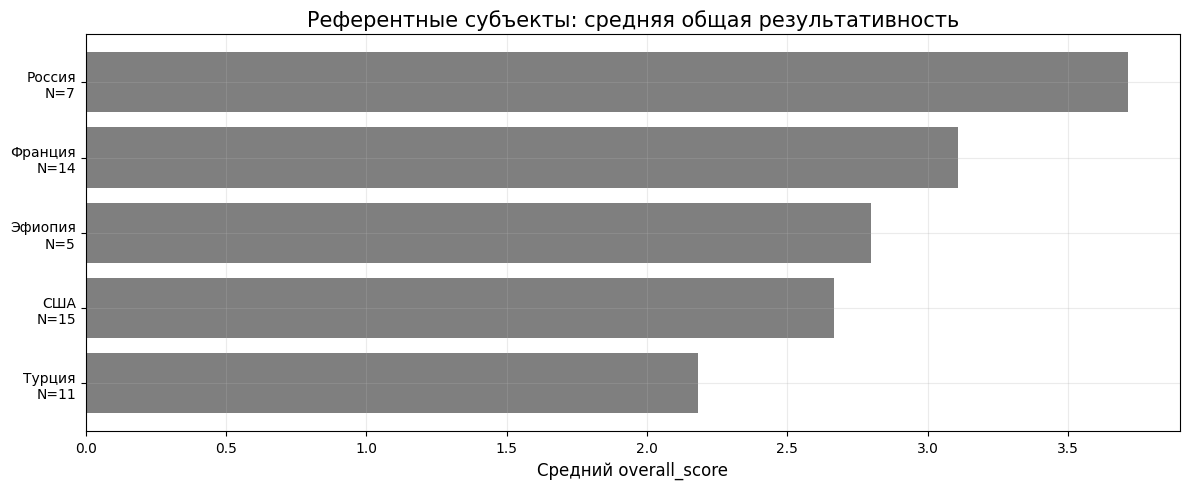

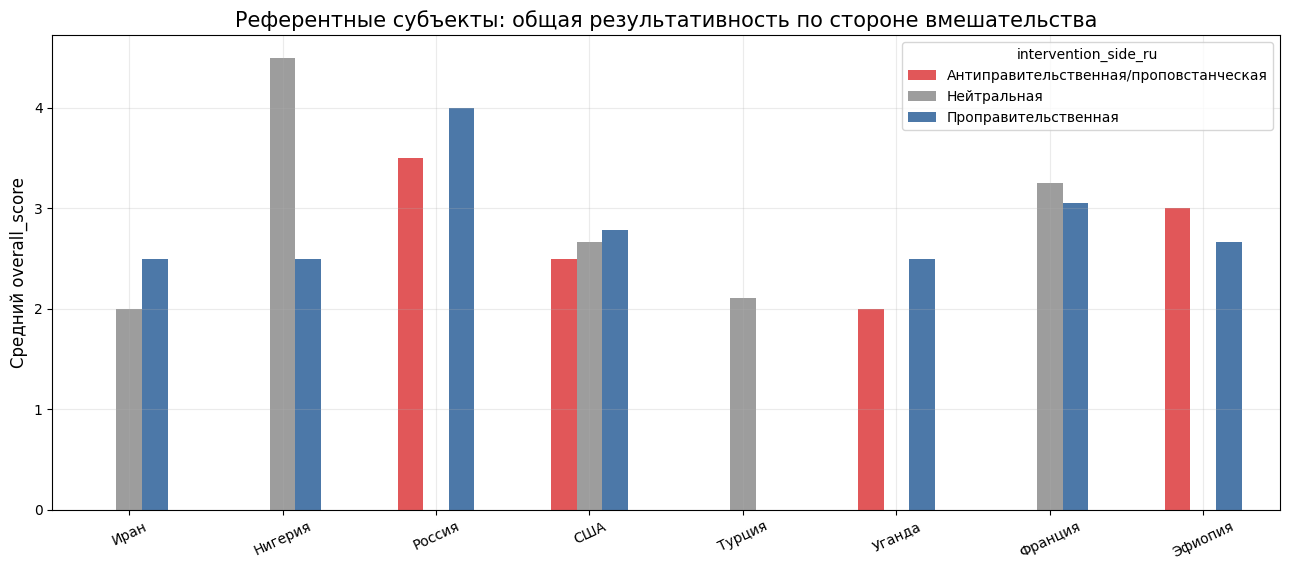

In [19]:
referent_col = "refsubject_ru_clean" if "refsubject_ru_clean" in df.columns else "refsubject_ru"

ref_df = df.copy()
ref_df["referent_subject"] = ref_df[referent_col].astype(str).str.replace(";", ",", regex=False).str.split(",")
ref_df = ref_df.explode("referent_subject")
ref_df["referent_subject"] = ref_df["referent_subject"].astype(str).str.strip()
ref_df = ref_df[
    ref_df["referent_subject"].notna()
    & ref_df["referent_subject"].ne("")
    & ref_df["referent_subject"].str.lower().ne("nan")
].copy()

referent_scores = [score for score in SCORES_EXTENDED if score in ref_df.columns]
referent_summary_df = (
    ref_df.groupby("referent_subject", as_index=False)
    .agg(
        N=("overall_score", "count"),
        mean_law_other_support_mean=("law_other_support_mean", "mean"),
        **{f"mean_{score}": (score, "mean") for score in referent_scores}
    )
    .round(3)
    .sort_values(["N", "mean_overall_score"], ascending=[False, False])
)

referent_tests = []
valid_subjects = ref_df["referent_subject"].value_counts()
valid_subjects = valid_subjects[valid_subjects >= 5].index
for score in referent_scores:
    groups = [
        group[score].dropna().values
        for _, group in ref_df[ref_df["referent_subject"].isin(valid_subjects)].groupby("referent_subject")
    ]
    groups = [values for values in groups if len(values) >= 5]
    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
    else:
        stat, p_value = np.nan, np.nan
    referent_tests.append({
        "score": score,
        "score_ru": SCORE_RU.get(score, score),
        "n_subjects": len(groups),
        "kruskal_stat": round(stat, 3) if pd.notna(stat) else np.nan,
        "p_value": round(p_value, 4) if pd.notna(p_value) else np.nan,
    })
referent_tests_df = pd.DataFrame(referent_tests)

ref_side_summary_df = (
    ref_df.groupby(["referent_subject", "intervention_side_final", "intervention_side_ru"], as_index=False)
    .agg(
        N=("overall_score", "count"),
        **{f"mean_{score}": (score, "mean") for score in referent_scores}
    )
    .round(3)
    .sort_values(["N", "mean_overall_score"], ascending=[False, False])
)

display(referent_summary_df)
display(referent_tests_df)
display(ref_side_summary_df)

ref_plot = referent_summary_df[referent_summary_df["N"].ge(5)].sort_values("mean_overall_score", ascending=True)
fig, ax = plt.subplots(figsize=(12, max(5, 0.35 * len(ref_plot) + 2)))
labels = ref_plot["referent_subject"] + "\nN=" + ref_plot["N"].astype(int).astype(str)
ax.barh(labels, ref_plot["mean_overall_score"], color="#7F7F7F")
ax.set_title("Референтные субъекты: средняя общая результативность")
ax.set_xlabel("Средний overall_score")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
save_current_figure("figure_referent_subjects_overall")
plt.show()

top_ref_subjects = ref_df["referent_subject"].value_counts().head(8).index
plot_df = ref_side_summary_df[
    ref_side_summary_df["referent_subject"].isin(top_ref_subjects)
    & ref_side_summary_df["N"].ge(2)
].copy()
pivot = plot_df.pivot_table(index="referent_subject", columns="intervention_side_ru", values="mean_overall_score")
if not pivot.empty:
    side_label_colors = {SIDE_RU[key]: value for key, value in SIDE_COLORS.items()}
    ax = pivot.plot(kind="bar", figsize=(13, 5.8), color=[side_label_colors.get(col, BLOCK_COLORS["other"]) for col in pivot.columns])
    ax.set_title("Референтные субъекты: общая результативность по стороне вмешательства")
    ax.set_xlabel("")
    ax.set_ylabel("Средний overall_score")
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_referent_subjects_by_side")
    plt.show()


## 8. Уровень 3: контекстуальные факторы

Проверяется связь задержки, длительности и базовых контекстуальных факторов с результативностью.


In [20]:
delay_corr = []

for score in scores:
    temp = df[["delay_months", score]].dropna()
    sp_corr, sp_p = spearmanr(temp["delay_months"], temp[score])
    pe_corr, pe_p = pearsonr(temp["delay_months"], temp[score])
    delay_corr.append({
        "score": score,
        "n": len(temp),
        "spearman_corr": round(sp_corr, 3),
        "spearman_p": round(sp_p, 4),
        "pearson_corr": round(pe_corr, 3),
        "pearson_p": round(pe_p, 4)
    })

delay_corr_df = pd.DataFrame(delay_corr)
delay_corr_df


,score,n,spearman_corr,spearman_p,pearson_corr,pearson_p
0,overall_score,101,-0.001,0.9938,-0.151,0.1307
1,mil_score_t1,97,0.012,0.9079,-0.055,0.5907
2,hum_score_t2,101,-0.007,0.9456,-0.116,0.2461
3,geo_score_t3,101,-0.053,0.5962,-0.143,0.1546


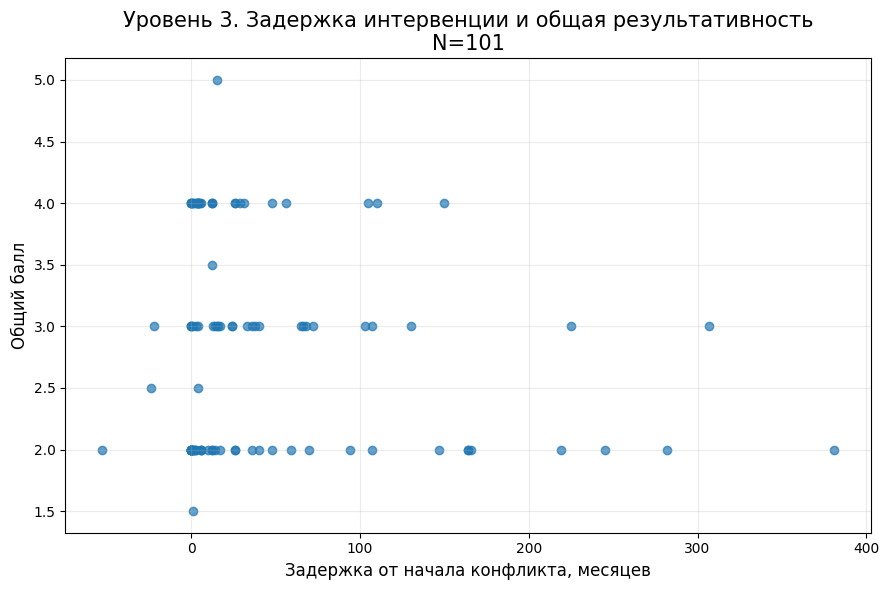

In [21]:
plot_delay_df = df[["delay_months", "overall_score"]].dropna()
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_delay_df["delay_months"], plot_delay_df["overall_score"], alpha=0.7)
ax.set_title(f"Уровень 3. Задержка интервенции и общая результативность\nN={len(plot_delay_df)}", fontsize=15)
ax.set_xlabel("Задержка от начала конфликта, месяцев", fontsize=12)
ax.set_ylabel("Общий балл", fontsize=12)
ax.grid(alpha=0.25)
plt.tight_layout()
save_current_figure("figure_20")
plt.show()


In [22]:
model_h3 = smf.ols("overall_score ~ duration_years + duration_sq", data=df).fit()

h3_table = model_table(model_h3, "H3_overall_duration")
h3_table


,model,variable,coef,p_value
0,H3_overall_duration,Intercept,2.7746,0.0000
1,H3_overall_duration,duration_years,0.0977,0.2107
2,H3_overall_duration,duration_sq,-0.0051,0.3145


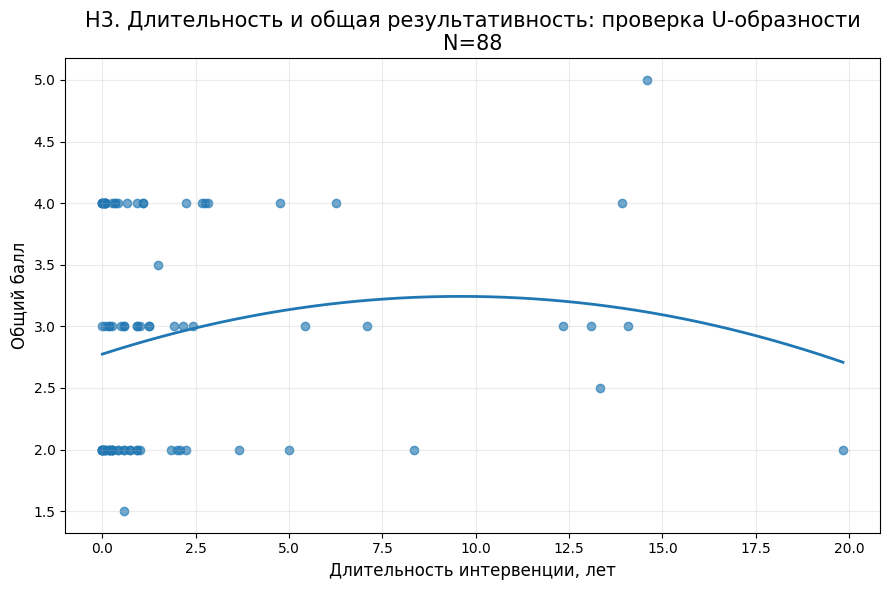

In [23]:
plot_df = df[["duration_years", "overall_score"]].dropna().sort_values("duration_years")
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_df["duration_years"], plot_df["overall_score"], alpha=0.65)
if len(plot_df) >= 10:
    coefs = np.polyfit(plot_df["duration_years"], plot_df["overall_score"], deg=2)
    xs = np.linspace(plot_df["duration_years"].min(), plot_df["duration_years"].max(), 200)
    ax.plot(xs, np.polyval(coefs, xs), linewidth=2)
ax.set_title(f"H3. Длительность и общая результативность: проверка U-образности\nN={len(plot_df)}", fontsize=15)
ax.set_xlabel("Длительность интервенции, лет", fontsize=12)
ax.set_ylabel("Общий балл", fontsize=12)
ax.grid(alpha=0.25)
plt.tight_layout()
save_current_figure("figure_21")
plt.show()


## 9. Поддержка, внимание и международная легитимация

Здесь сопоставляются показатели политической поддержки, внимания и международно-правовой легитимации с результативностью и целями.


In [24]:
h4_predictors = [v for v in support_vars if df[v].notna().sum() >= 10]
if h4_predictors:
    h4_rhs = " + ".join(h4_predictors)
    model_h4_hum = smf.ols(f"hum_score_t2 ~ {h4_rhs}", data=df).fit()
    model_h4_mil = smf.ols(f"mil_score_t1 ~ {h4_rhs}", data=df).fit()
    h4_table = pd.concat([
        model_table(model_h4_hum, "H4_hum_support"),
        model_table(model_h4_mil, "H4_mil_support")
    ], ignore_index=True)
else:
    h4_table = pd.DataFrame([{"message": "Недостаточно непустых переменных поддержки для OLS"}])
h4_table


,model,variable,coef,p_value
0,H4_hum_support,Intercept,2.8020,0.0000
1,H4_hum_support,law_other,0.1390,0.5585
2,H4_hum_support,law_other_mean,-0.1960,0.6777
3,H4_hum_support,law_other_support_mean,0.2251,0.5586
4,H4_mil_support,Intercept,3.8501,0.0000
5,H4_mil_support,law_other,-0.0042,0.9845
6,H4_mil_support,law_other_mean,-0.2081,0.6035
7,H4_mil_support,law_other_support_mean,0.0904,0.7800


In [25]:
context_vars = support_vars
context_corr = []

for var in context_vars:
    for score in scores:
        n, corr, p = safe_spearman(df, var, score, min_n=5)
        context_corr.append({
            "context_var": var,
            "context_var_ru": SUPPORT_LABELS[var],
            "score": score,
            "score_ru": SCORE_RU[score],
            "n": n,
            "spearman_corr": corr,
            "p_value": p,
        })

context_corr_df = pd.DataFrame(context_corr)
context_corr_df


,context_var,context_var_ru,score,score_ru,n,spearman_corr,p_value
0,law_other,Международно-правовая поддержка,overall_score,Общая результативность,101,0.146,0.1450
1,law_other,Международно-правовая поддержка,mil_score_t1,Военная результативность,97,-0.107,0.2956
2,law_other,Международно-правовая поддержка,hum_score_t2,Гуманитарная результативность,101,0.137,0.1707
3,law_other,Международно-правовая поддержка,geo_score_t3,Геополитическая результативность,101,0.077,0.4452
4,law_other_mean,Политическая поддержка со стороны великих держав,overall_score,Общая результативность,100,0.113,0.2612
5,law_other_mean,Политическая поддержка со стороны великих держав,mil_score_t1,Военная результативность,96,-0.126,0.2201
6,law_other_mean,Политическая поддержка со стороны великих держав,hum_score_t2,Гуманитарная результативность,100,0.099,0.3287
7,law_other_mean,Политическая поддержка со стороны великих держав,geo_score_t3,Геополитическая результативность,100,0.105,0.2978
8,law_other_support_mean,Политическая поддержка,overall_score,Общая результативность,94,0.109,0.2955
9,law_other_support_mean,Политическая поддержка,mil_score_t1,Военная результативность,90,-0.094,0.3772


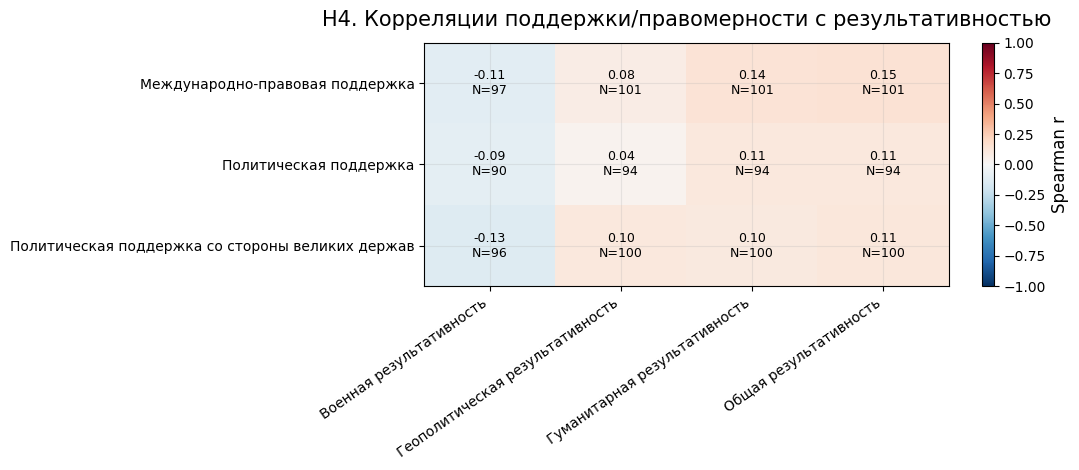

In [26]:
plot_corr_heatmap(
    context_corr_df,
    row_col="context_var_ru", col_col="score_ru", value_col="spearman_corr", n_col="n",
    title="H4. Корреляции поддержки/правомерности с результативностью",
    figsize=(11, 4.8)
)
save_current_figure("figure_22")
plt.show()


,model,variable,coef,p_value
0,H4_hum_support_attention,Intercept,2.5101,0.0000
1,H4_hum_support_attention,support_index,0.2399,0.0238
2,H4_hum_support_attention,attention_index,0.6347,0.0694
3,H4_mil_support_attention,Intercept,3.5196,0.0000
4,H4_mil_support_attention,support_index,0.0018,0.9851
5,H4_mil_support_attention,attention_index,0.6210,0.0556


,context_var,context_var_ru,score,score_ru,n,spearman_corr,p_value
0,support_index,Общая поддержка,overall_score,Общая результативность,94,0.304,0.0029
1,support_index,Общая поддержка,mil_score_t1,Военная результативность,90,0.019,0.8566
2,support_index,Общая поддержка,hum_score_t2,Гуманитарная результативность,94,0.294,0.0041
3,support_index,Общая поддержка,geo_score_t3,Геополитическая результативность,94,0.254,0.0136
4,media_support_index,Медийная поддержка,overall_score,Общая результативность,82,0.303,0.0057
5,media_support_index,Медийная поддержка,mil_score_t1,Военная результативность,78,0.060,0.6046
6,media_support_index,Медийная поддержка,hum_score_t2,Гуманитарная результативность,82,0.261,0.0180
7,media_support_index,Медийная поддержка,geo_score_t3,Геополитическая результативность,82,0.341,0.0017
8,attention_index,Внимание,overall_score,Общая результативность,101,0.074,0.4635
9,attention_index,Внимание,mil_score_t1,Военная результативность,97,0.184,0.0710


,model,variable,coef,p_value
0,overall_support_attention,Intercept,2.5605,0.0000
1,overall_support_attention,delay_months,-0.0019,0.1496
2,overall_support_attention,duration_years,0.1102,0.2158
3,overall_support_attention,duration_sq,-0.0058,0.3046
4,overall_support_attention,support_index,0.1890,0.1056
5,overall_support_attention,attention_index,0.5463,0.1474
6,mil_support_attention,Intercept,3.5721,0.0000
7,mil_support_attention,delay_months,-0.0004,0.7242
8,mil_support_attention,duration_years,0.0192,0.8155
9,mil_support_attention,duration_sq,-0.0010,0.8414


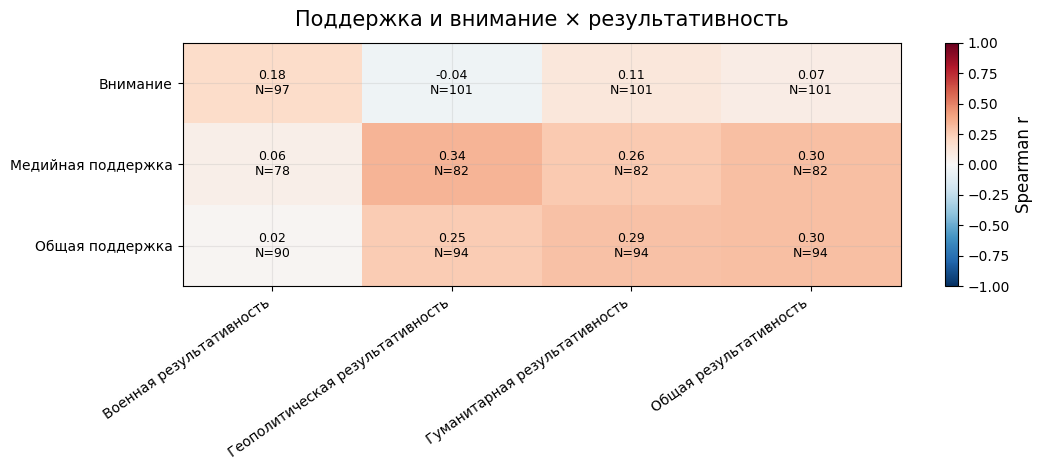

In [27]:
ethics_file = find_file(ETHICS_FILE)
eth = pd.read_excel(ethics_file, sheet_name="int_ethics_main")

eth["i_dyad_id"] = eth["i_dyad_id"].astype(str).str.strip()
df["i_dyad_id"] = df["i_dyad_id"].astype(str).str.strip()
eth_cols = [
    "i_dyad_id",
    "approval_all_before_and_after",
    "approval_newsmedia_before_and_after",
    "attention_all_before_and_after",
]
missing_eth_cols = [c for c in eth_cols if c not in eth.columns]
if missing_eth_cols:
    raise ValueError("Не найдены переменные поддержки и внимания: " + ", ".join(missing_eth_cols))

support_attention_vars = eth[eth_cols].drop_duplicates("i_dyad_id", keep="first").copy()
for col in eth_cols[1:] + ["support_index", "media_support_index", "attention_index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(support_attention_vars, on="i_dyad_id", how="left")
df["support_index"] = pd.to_numeric(df["approval_all_before_and_after"], errors="coerce")
df["media_support_index"] = pd.to_numeric(df["approval_newsmedia_before_and_after"], errors="coerce")
df["attention_index"] = pd.to_numeric(df["attention_all_before_and_after"], errors="coerce")
attention_context_vars = ["support_index", "media_support_index", "attention_index"]
ATTENTION_CONTEXT_LABELS = {
    "support_index": "Общая поддержка",
    "media_support_index": "Медийная поддержка",
    "attention_index": "Внимание",
}
attention_support_coverage_df = pd.DataFrame([
    {
        "variable": ATTENTION_CONTEXT_LABELS[var],
        "N": int(df[var].notna().sum()),
        "mean": round(df[var].mean(), 3),
        "std": round(df[var].std(ddof=1), 3),
    }
    for var in attention_context_vars
])

model_h4_attention_hum = smf.ols("hum_score_t2 ~ support_index + attention_index", data=df).fit()
model_h4_attention_mil = smf.ols("mil_score_t1 ~ support_index + attention_index", data=df).fit()
attention_h4_table = pd.concat([
    model_table(model_h4_attention_hum, "H4_hum_support_attention"),
    model_table(model_h4_attention_mil, "H4_mil_support_attention"),
], ignore_index=True)

attention_context_corr = []
for var in attention_context_vars:
    for score in scores:
        n, corr, p = safe_spearman(df, var, score, min_n=5)
        attention_context_corr.append({
            "context_var": var,
            "context_var_ru": ATTENTION_CONTEXT_LABELS[var],
            "score": score,
            "score_ru": SCORE_RU[score],
            "n": n,
            "spearman_corr": corr,
            "p_value": p,
        })
attention_context_corr_df = pd.DataFrame(attention_context_corr)

attention_model_level3_full = smf.ols("overall_score ~ delay_months + duration_years + duration_sq + support_index + attention_index", data=df).fit()
attention_model_level3_mil = smf.ols("mil_score_t1 ~ delay_months + duration_years + duration_sq + support_index + attention_index", data=df).fit()
attention_model_level3_hum = smf.ols("hum_score_t2 ~ delay_months + duration_years + duration_sq + support_index + attention_index", data=df).fit()
attention_model_level3_geo = smf.ols("geo_score_t3 ~ delay_months + duration_years + duration_sq + support_index + attention_index", data=df).fit()
attention_level3_models = pd.concat([
    model_table(attention_model_level3_full, "overall_support_attention"),
    model_table(attention_model_level3_mil, "mil_support_attention"),
    model_table(attention_model_level3_hum, "hum_support_attention"),
    model_table(attention_model_level3_geo, "geo_support_attention"),
], ignore_index=True)

display(attention_h4_table)
display(attention_context_corr_df)
display(attention_level3_models)

plot_corr_heatmap(
    attention_context_corr_df,
    row_col="context_var_ru", col_col="score_ru", value_col="spearman_corr", n_col="n",
    title="Поддержка и внимание × результативность",
    figsize=(11, 4.8)
)
save_current_figure("figure_01")
plt.show()


,context_var,context_var_ru,score,score_ru,n,spearman_corr,p_value
0,law_other,Международно-правовая поддержка,overall_score,Общая результативность,101,0.146,0.1450
1,law_other,Международно-правовая поддержка,mil_score_t1,Военная результативность,97,-0.107,0.2956
2,law_other,Международно-правовая поддержка,hum_score_t2,Гуманитарная результативность,101,0.137,0.1707
3,law_other,Международно-правовая поддержка,geo_score_t3,Геополитическая результативность,101,0.077,0.4452
4,law_other_mean,Политическая поддержка со стороны великих держав,overall_score,Общая результативность,100,0.113,0.2612
5,law_other_mean,Политическая поддержка со стороны великих держав,mil_score_t1,Военная результативность,96,-0.126,0.2201
6,law_other_mean,Политическая поддержка со стороны великих держав,hum_score_t2,Гуманитарная результативность,100,0.099,0.3287
7,law_other_mean,Политическая поддержка со стороны великих держав,geo_score_t3,Геополитическая результативность,100,0.105,0.2978
8,law_other_support_mean,Политическая поддержка,overall_score,Общая результативность,94,0.109,0.2955
9,law_other_support_mean,Политическая поддержка,mil_score_t1,Военная результативность,90,-0.094,0.3772


,context_var,context_var_ru,goal,goal_ru,goal_block,goal_block_ru,profile_score,profile_score_ru,n,spearman_corr,p_value
9,law_other,Международно-правовая поддержка,geopolitical_counternonstate,Геополитическая: против негос. акторов,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,36,-0.045,0.7966
21,law_other_mean,Политическая поддержка со стороны великих держав,geopolitical_counternonstate,Геополитическая: против негос. акторов,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,35,0.023,0.8954
33,law_other_support_mean,Политическая поддержка,geopolitical_counternonstate,Геополитическая: против негос. акторов,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,34,-0.103,0.5616
10,law_other,Международно-правовая поддержка,geopolitical_position,Геополитическая: усиление позиции,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,35,0.002,0.9897
22,law_other_mean,Политическая поддержка со стороны великих держав,geopolitical_position,Геополитическая: усиление позиции,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,35,-0.069,0.6929
34,law_other_support_mean,Политическая поддержка,geopolitical_position,Геополитическая: усиление позиции,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,33,-0.020,0.9134
11,law_other,Международно-правовая поддержка,geopolitical_preemption,Геополитическая: предупреждение угрозы,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,7,-0.683,0.0907
23,law_other_mean,Политическая поддержка со стороны великих держав,geopolitical_preemption,Геополитическая: предупреждение угрозы,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,7,-1.000,0.0000
35,law_other_support_mean,Политическая поддержка,geopolitical_preemption,Геополитическая: предупреждение угрозы,geopolitical,Геополитические цели,geo_score_t3,Геополитическая результативность,7,-0.764,0.0457
5,law_other,Международно-правовая поддержка,consequences_humanitarian,Гуманитарная: защита населения,humanitarian,Гуманитарные цели,hum_score_t2,Гуманитарная результативность,40,-0.195,0.2271


,intervention_side_final,intervention_side_ru,context_var,context_var_ru,score,score_ru,n,spearman_corr,p_value
0,neutral,Нейтральная,law_other,Международно-правовая поддержка,overall_score,Общая результативность,31,0.487,0.0055
1,neutral,Нейтральная,law_other,Международно-правовая поддержка,hum_score_t2,Гуманитарная результативность,31,0.467,0.0080
2,neutral,Нейтральная,law_other,Международно-правовая поддержка,mil_score_t1,Военная результативность,31,-0.050,0.7877
3,neutral,Нейтральная,law_other,Международно-правовая поддержка,geo_score_t3,Геополитическая результативность,31,0.393,0.0288
4,neutral,Нейтральная,law_other_mean,Политическая поддержка со стороны великих держав,overall_score,Общая результативность,30,0.478,0.0075
5,neutral,Нейтральная,law_other_mean,Политическая поддержка со стороны великих держав,hum_score_t2,Гуманитарная результативность,30,0.447,0.0133
6,neutral,Нейтральная,law_other_mean,Политическая поддержка со стороны великих держав,mil_score_t1,Военная результативность,30,0.068,0.7210
7,neutral,Нейтральная,law_other_mean,Политическая поддержка со стороны великих держав,geo_score_t3,Геополитическая результативность,30,0.500,0.0049
8,neutral,Нейтральная,law_other_support_mean,Политическая поддержка,overall_score,Общая результативность,28,0.375,0.0496
9,neutral,Нейтральная,law_other_support_mean,Политическая поддержка,hum_score_t2,Гуманитарная результативность,28,0.359,0.0610


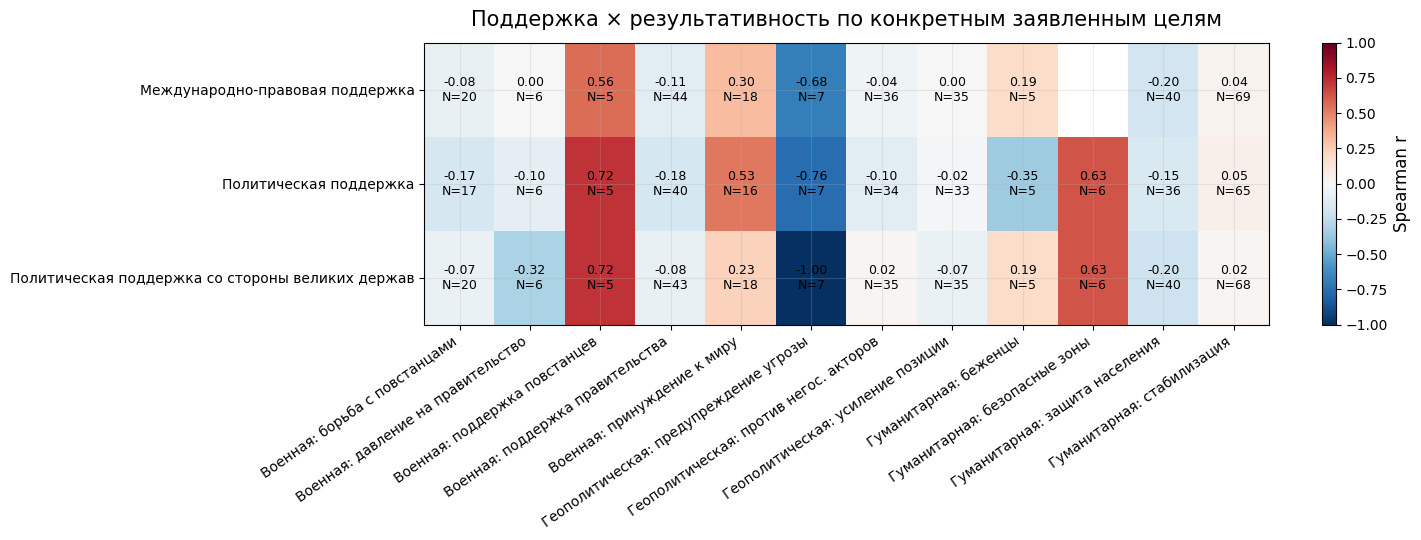

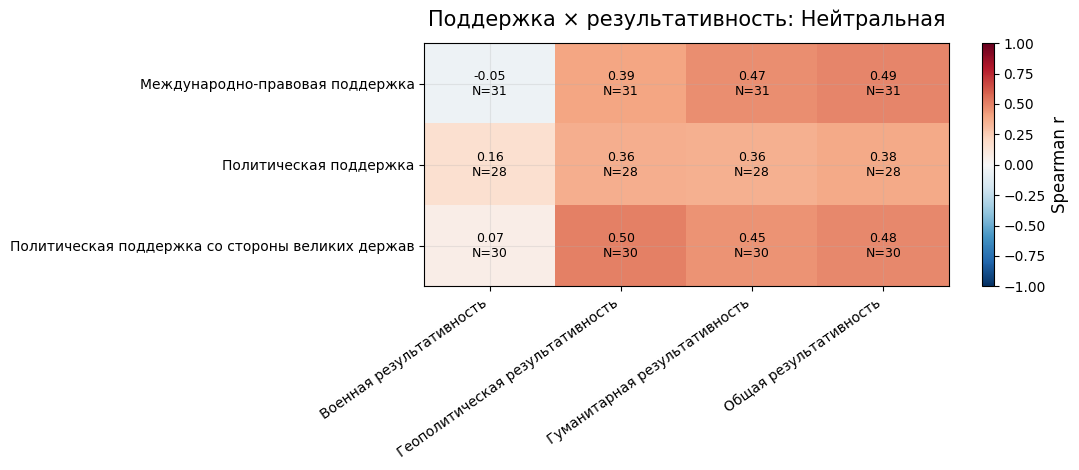

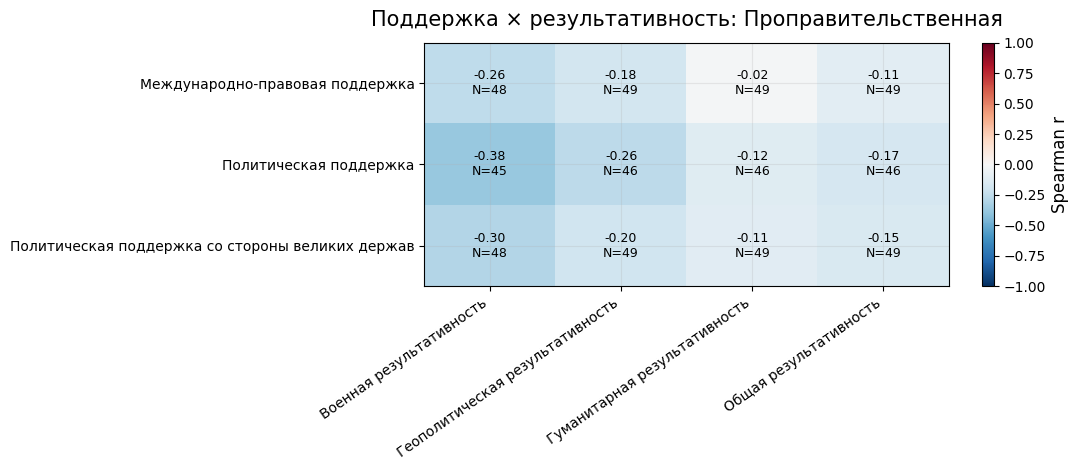

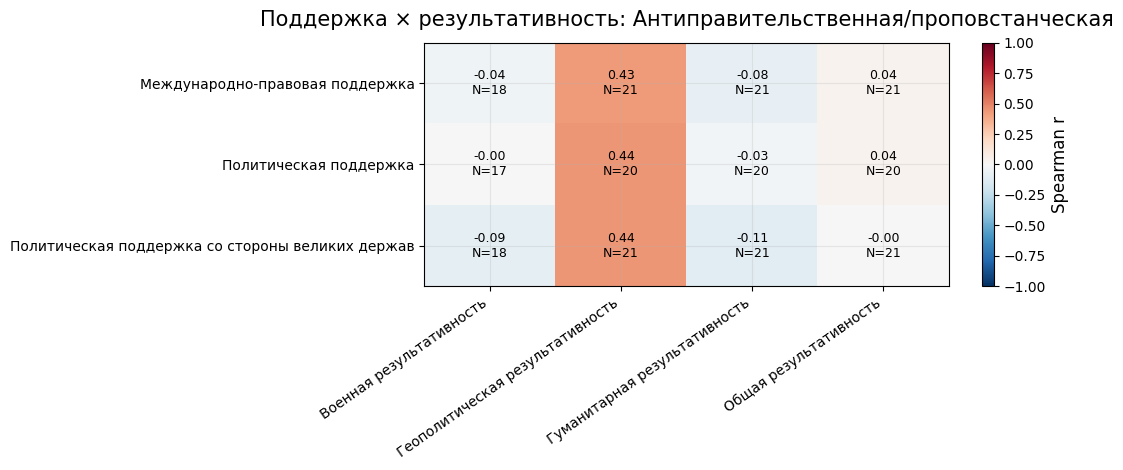

In [28]:
support_score_correlations_df = context_corr_df.copy()

support_goal_corr_rows = []
for var in support_vars:
    for goal, profile_score in goal_to_score.items():
        subset = df[df[goal].eq(1)].copy()
        n, corr, p = safe_spearman(subset, var, profile_score, min_n=5)
        support_goal_corr_rows.append({
            "context_var": var,
            "context_var_ru": SUPPORT_LABELS[var],
            "goal": goal,
            "goal_ru": ru_goal(goal),
            "goal_block": GOAL_BLOCK[goal],
            "goal_block_ru": BLOCK_RU[GOAL_BLOCK[goal]],
            "profile_score": profile_score,
            "profile_score_ru": SCORE_RU[profile_score],
            "n": n,
            "spearman_corr": corr,
            "p_value": p,
        })
support_goal_correlations_df = pd.DataFrame(support_goal_corr_rows)

support_side_corr_rows = []
for side, subset in df.groupby("intervention_side_final", dropna=True):
    for var in support_vars:
        for score in ["overall_score", "hum_score_t2", "mil_score_t1", "geo_score_t3"]:
            n, corr, p = safe_spearman(subset, var, score, min_n=5)
            support_side_corr_rows.append({
                "intervention_side_final": side,
                "intervention_side_ru": SIDE_RU.get(side, side),
                "context_var": var,
                "context_var_ru": SUPPORT_LABELS[var],
                "score": score,
                "score_ru": SCORE_RU[score],
                "n": n,
                "spearman_corr": corr,
                "p_value": p,
            })
support_correlations_by_side_df = pd.DataFrame(support_side_corr_rows)

display(support_score_correlations_df)
display(support_goal_correlations_df.sort_values(["goal_block", "goal", "context_var"]))
display(support_correlations_by_side_df)


support_goal_heat = support_goal_correlations_df.dropna(subset=["spearman_corr"]).copy()
if not support_goal_heat.empty:
    support_goal_heat = support_goal_heat[support_goal_heat["n"] >= 5].copy()
    plot_corr_heatmap(
        support_goal_heat,
        row_col="context_var_ru", col_col="goal_ru", value_col="spearman_corr", n_col="n",
        title="Поддержка × результативность по конкретным заявленным целям",
        figsize=(15, 5.5)
    )
    save_current_figure("figure_02")
    plt.show()
for side in support_correlations_by_side_df["intervention_side_final"].dropna().unique():
    subset = support_correlations_by_side_df[
        support_correlations_by_side_df["intervention_side_final"].eq(side)
        & support_correlations_by_side_df["n"].ge(5)
    ].copy()
    plot_corr_heatmap(
        subset,
        row_col="context_var_ru", col_col="score_ru", value_col="spearman_corr", n_col="n",
        title=f"Поддержка × результативность: {SIDE_RU.get(side, side)}",
        figsize=(11, 4.8)
    )
    save_current_figure("figure_03")
    plt.show()


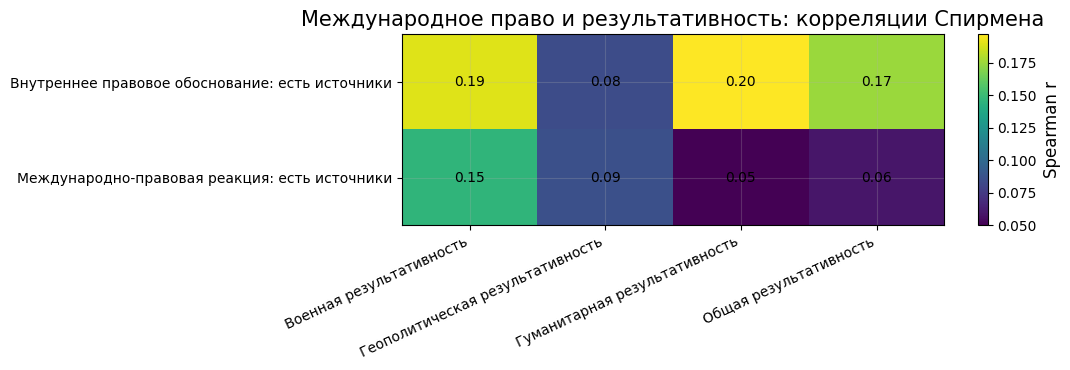

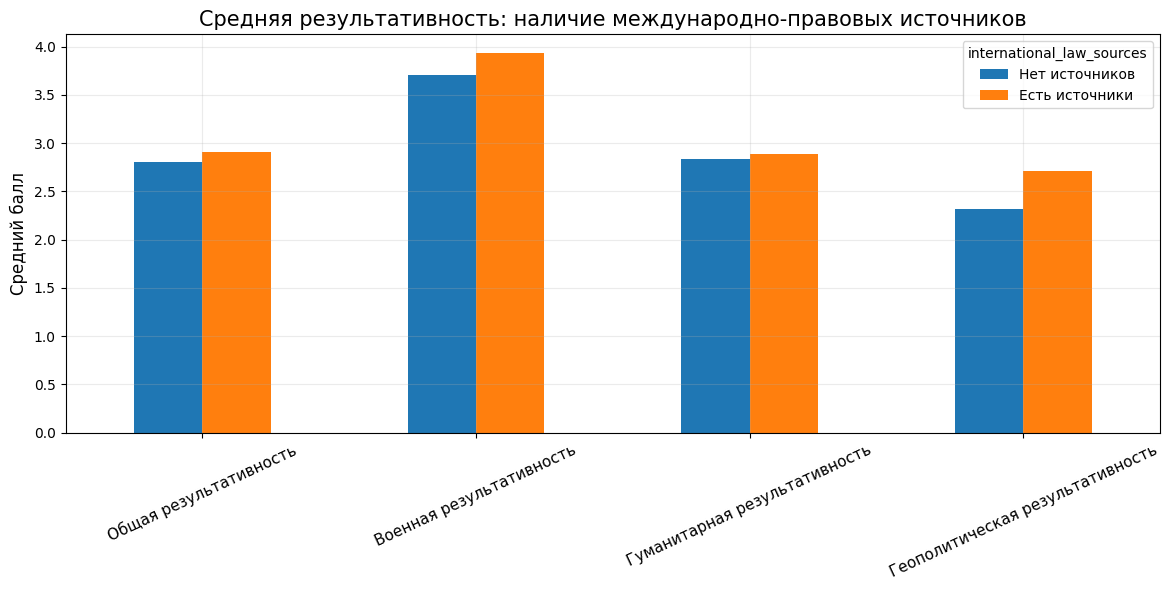

In [29]:
try:
    law_raw = pd.read_excel(find_file("Копия ethics_copy.xlsx"), sheet_name="Copy of i_main", header=1)
except Exception:
    law_raw = pd.read_excel(find_file("Копия ethics_copy.xlsx"), sheet_name="Copy of i_main 1", header=1)

law_raw["i_dyad_id"] = law_raw["i_dyad_id"].astype(str).str.strip()

law_cols = [c for c in ["i_dyad_id", "oldsource_lawgreat", "oldsource_lawself"] if c in law_raw.columns]
law_vars = law_raw[law_cols].copy()

def has_nonempty_source(series):
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan, "missing": np.nan})
    return int(s.notna().any())

agg_dict = {}
if "oldsource_lawgreat" in law_vars.columns:
    agg_dict["oldsource_lawgreat"] = has_nonempty_source
if "oldsource_lawself" in law_vars.columns:
    agg_dict["oldsource_lawself"] = has_nonempty_source

law_vars = law_vars.groupby("i_dyad_id", as_index=False).agg(agg_dict)

law_vars = law_vars.rename(columns={
    "oldsource_lawgreat": "international_law_sources",
    "oldsource_lawself": "domestic_law_sources",
})

for col in ["international_law_sources", "domestic_law_sources"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(law_vars, on="i_dyad_id", how="left")

for col in ["international_law_sources", "domestic_law_sources"]:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

law_coverage_df = pd.DataFrame([
    {
        "law_var": col,
        "description": "Источники по международно-правовой реакции" if col == "international_law_sources" else "Источники по внутреннему/собственному правовому обоснованию",
        "n_with_sources": int(df[col].sum()),
        "n_without_sources": int((df[col] == 0).sum()),
        "share_with_sources": round(float(df[col].mean()), 3)
    }
    for col in ["international_law_sources", "domestic_law_sources"]
    if col in df.columns
])

law_coverage_df


law_context_vars = [c for c in ["international_law_sources", "domestic_law_sources"] if c in df.columns]

LAW_RU = {
    "international_law_sources": "Международно-правовая реакция: есть источники",
    "domestic_law_sources": "Внутреннее правовое обоснование: есть источники",
}

law_corr = []
for var in law_context_vars:
    for score in scores:
        temp = df[[var, score]].dropna()
        if len(temp) >= 3 and temp[var].nunique() > 1:
            corr, p = spearmanr(temp[var], temp[score])
        else:
            corr, p = np.nan, np.nan
        law_corr.append({
            "context_var": LAW_RU.get(var, var),
            "score": SCORE_RU.get(score, score),
            "n": len(temp),
            "spearman_corr": round(corr, 3) if pd.notna(corr) else np.nan,
            "p_value": round(p, 4) if pd.notna(p) else np.nan,
        })

law_corr_df = pd.DataFrame(law_corr)
law_corr_df


law_heat = law_corr_df.pivot(index="context_var", columns="score", values="spearman_corr")

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(law_heat.values, aspect="auto")
ax.set_xticks(range(law_heat.shape[1]), law_heat.columns, rotation=25, ha="right")
ax.set_yticks(range(law_heat.shape[0]), law_heat.index)
ax.set_title("Международное право и результативность: корреляции Спирмена", fontsize=15)
for i in range(law_heat.shape[0]):
    for j in range(law_heat.shape[1]):
        val = law_heat.iloc[i, j]
        ax.text(j, i, f"{val:.2f}" if pd.notna(val) else "", ha="center", va="center")
plt.colorbar(im, ax=ax, label="Spearman r")
plt.tight_layout()
save_current_figure("figure_09")
plt.show()


if "international_law_sources" in df.columns:
    law_mean_plot = (
        df.groupby("international_law_sources")[scores]
        .mean()
        .T
        .reset_index()
        .rename(columns={0: "Нет источников", 1: "Есть источники"})
    )
    law_mean_plot["score_ru"] = law_mean_plot["index"].map(SCORE_RU)

    y_cols = [c for c in ["Нет источников", "Есть источники"] if c in law_mean_plot.columns]
    ax = law_mean_plot.plot(x="score_ru", y=y_cols, kind="bar", figsize=(12, 6))
    ax.set_title("Средняя результативность: наличие международно-правовых источников", fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("Средний балл", fontsize=12)
    ax.tick_params(axis="x", labelrotation=25, labelsize=11)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_10")
    plt.show()


## 10. Геополитическая декомпозиция

Геополитическая результативность раскладывается на индикаторы угрозы, стабильности, сохранения режима и стабилизации. Это позволяет увидеть, какие показатели тянут агрегированный результат вверх или вниз.


,goal,goal_ru,indicator,indicator_ru,dimension,raw_variable,N,mean_normalized,median_normalized,raw_mean,geo_score_mean
0,geopolitical_counternonstate,Геополитическая: против негос. акторов,geo_threat_t3,Динамика угрозы,Угроза,geo_threat_t3,36,0.194,0.000,0.194,2.306
1,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_attacks_reduction,Снижение числа атак НВФ,Насилие,nonstate_attacks_t1,36,0.563,0.562,-9.500,2.306
2,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_casualties_reduction,Снижение потерь от действий НВФ,Насилие,nonstate_combatant_casualties_t1,36,0.643,0.644,44.917,2.306
3,geopolitical_position,Геополитическая: усиление позиции,pol_democracy_change_t3,Демократическая динамика,Дополнительный outcome,pol_democracy_change_t3,24,0.250,0.250,2.000,2.057
4,geopolitical_position,Геополитическая: усиление позиции,pol_regime_survival_t3,Сохранение режима,Политическая устойчивость,pol_regime_survival_t3,35,1.000,1.000,1.000,2.057
5,geopolitical_position,Геополитическая: усиление позиции,pol_stability_t3,Стабильность / снижение насилия,Политическая устойчивость,pol_stability_t3,35,0.086,0.000,0.086,2.057
6,geopolitical_position,Геополитическая: усиление позиции,pol_stabilization_t3,Региональная стабилизация,Стабилизация,pol_stabilization_t3,35,0.000,0.000,0.000,2.057
7,geopolitical_preemption,Геополитическая: предупреждение угрозы,geo_threat_t3,Динамика угрозы,Угроза,geo_threat_t3,7,0.000,0.000,0.000,1.857
8,geopolitical_preemption,Геополитическая: предупреждение угрозы,nonstate_attacks_reduction,Снижение числа атак НВФ,Насилие,nonstate_attacks_t1,7,0.482,0.562,607.000,1.857
9,geopolitical_preemption,Геополитическая: предупреждение угрозы,nonstate_casualties_reduction,Снижение потерь от действий НВФ,Насилие,nonstate_combatant_casualties_t1,7,0.552,0.644,4660.000,1.857


,goal,goal_ru,indicator,indicator_ru,goal_declared_ru,N,mean_normalized,raw_mean
0,geopolitical_counternonstate,Геополитическая: против негос. акторов,geo_threat_t3,Динамика угрозы,цель заявлена,36,0.194,0.194
1,geopolitical_counternonstate,Геополитическая: против негос. акторов,geo_threat_t3,Динамика угрозы,цель не заявлена,65,0.277,0.277
2,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_attacks_reduction,Снижение числа атак НВФ,цель заявлена,36,0.563,-9.500
3,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_attacks_reduction,Снижение числа атак НВФ,цель не заявлена,65,0.567,-37.892
4,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_casualties_reduction,Снижение потерь от действий НВФ,цель заявлена,36,0.643,44.917
5,geopolitical_counternonstate,Геополитическая: против негос. акторов,nonstate_casualties_reduction,Снижение потерь от действий НВФ,цель не заявлена,65,0.646,-109.846
6,geopolitical_position,Геополитическая: усиление позиции,pol_democracy_change_t3,Демократическая динамика,цель заявлена,24,0.250,2.000
7,geopolitical_position,Геополитическая: усиление позиции,pol_democracy_change_t3,Демократическая динамика,цель не заявлена,44,0.330,2.318
8,geopolitical_position,Геополитическая: усиление позиции,pol_regime_survival_t3,Сохранение режима,цель заявлена,35,1.000,1.000
9,geopolitical_position,Геополитическая: усиление позиции,pol_regime_survival_t3,Сохранение режима,цель не заявлена,66,0.924,0.924


,goal,goal_ru,weakest_indicator,weakest_mean,strongest_indicator,strongest_mean
0,geopolitical_counternonstate,Геополитическая: против негос. акторов,Динамика угрозы,0.194,Снижение потерь от действий НВФ,0.643
1,geopolitical_position,Геополитическая: усиление позиции,Региональная стабилизация,0.000,Сохранение режима,1.000
2,geopolitical_preemption,Геополитическая: предупреждение угрозы,Динамика угрозы,0.000,Снижение потерь от действий НВФ,0.552


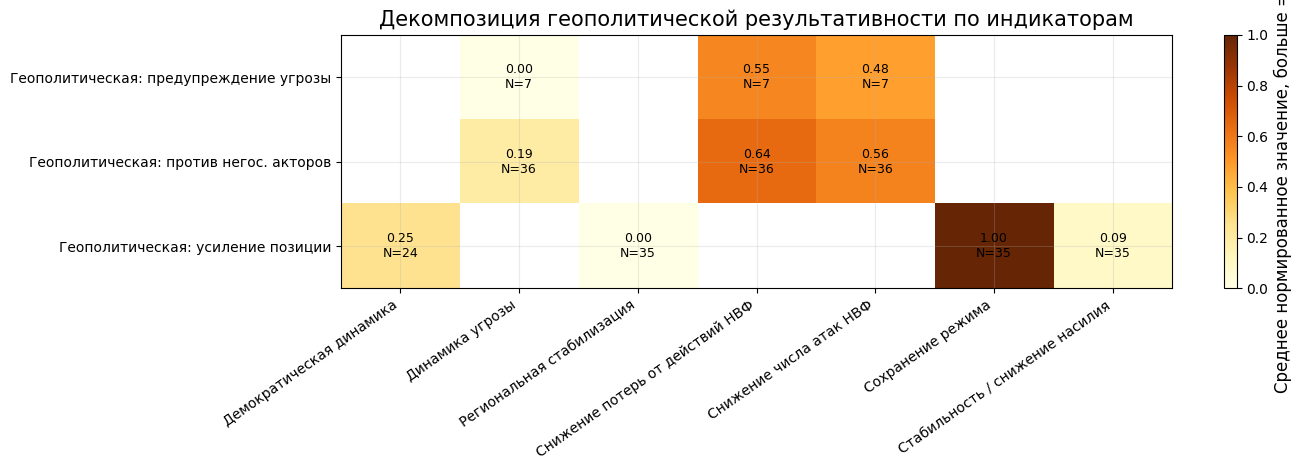

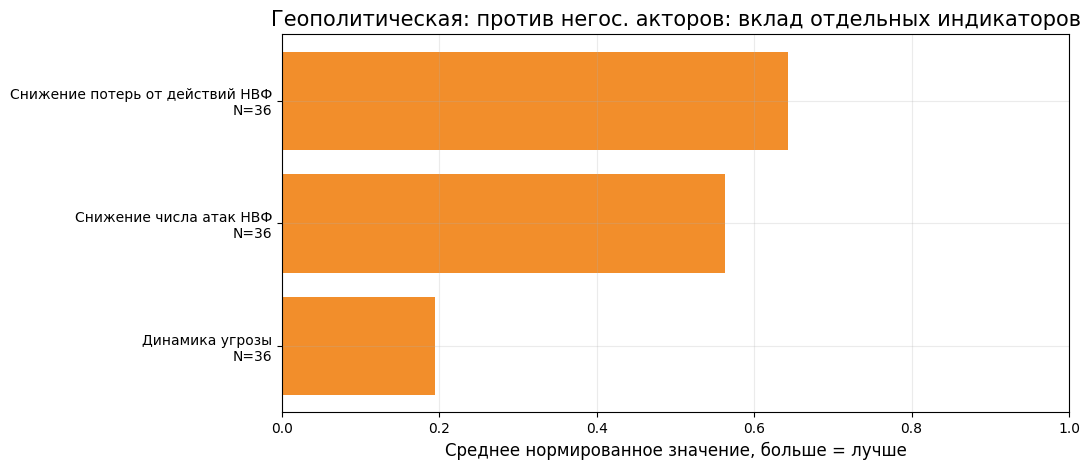

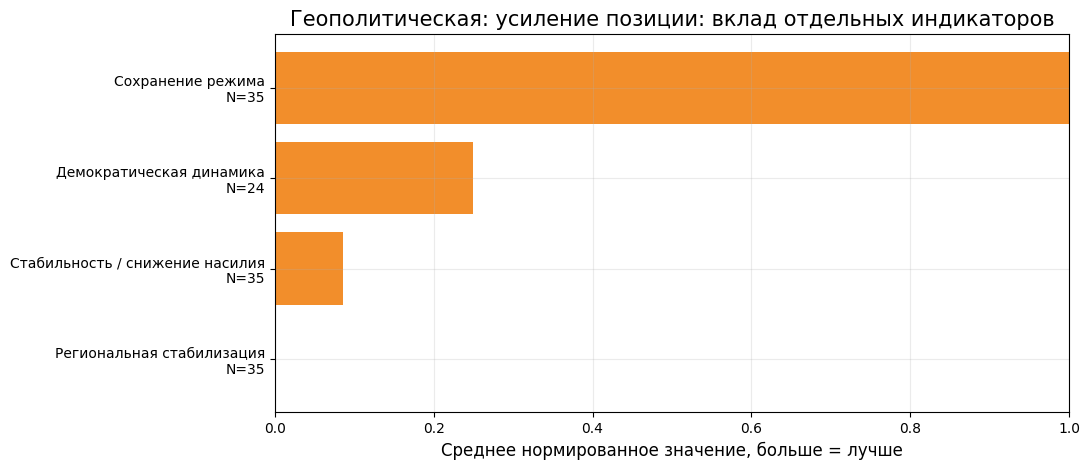

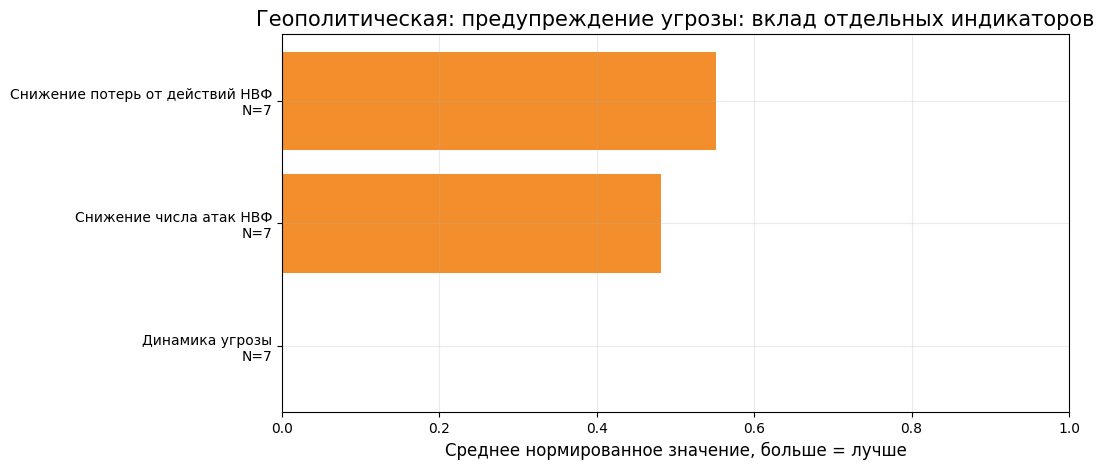

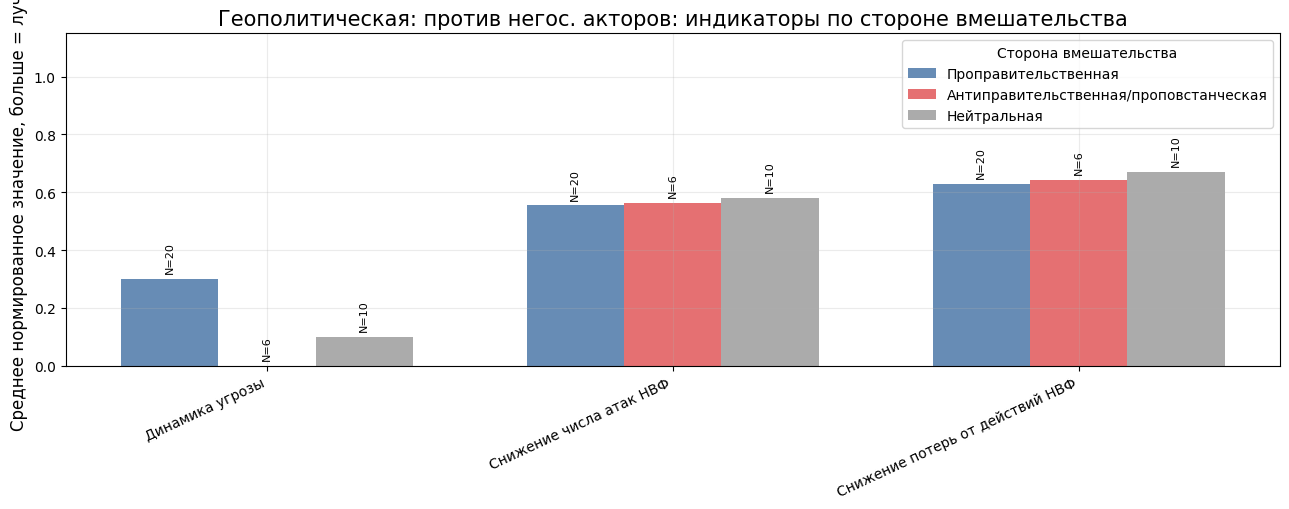

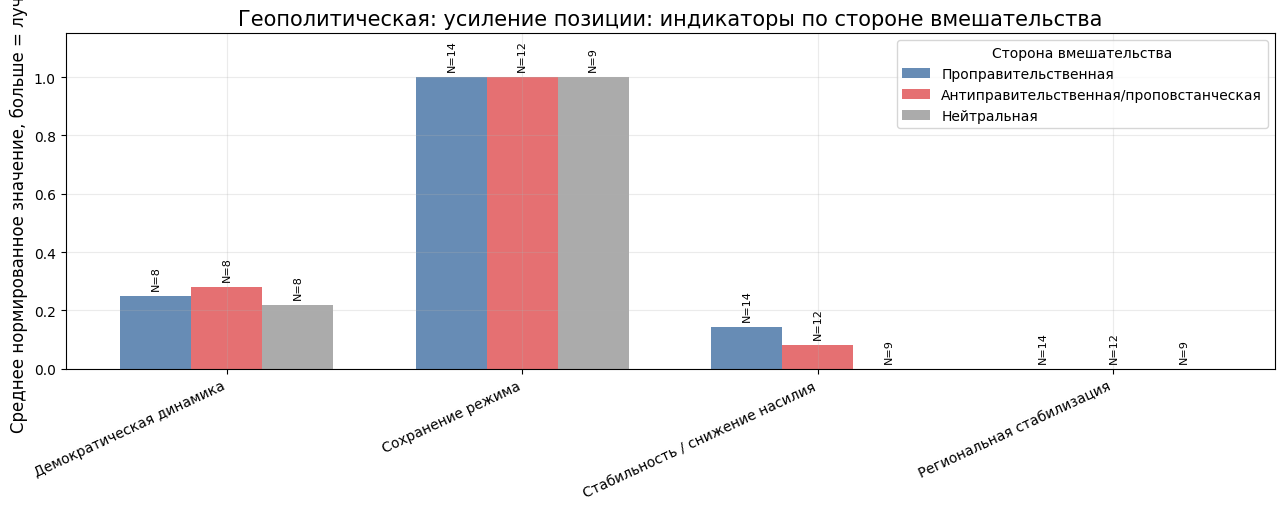

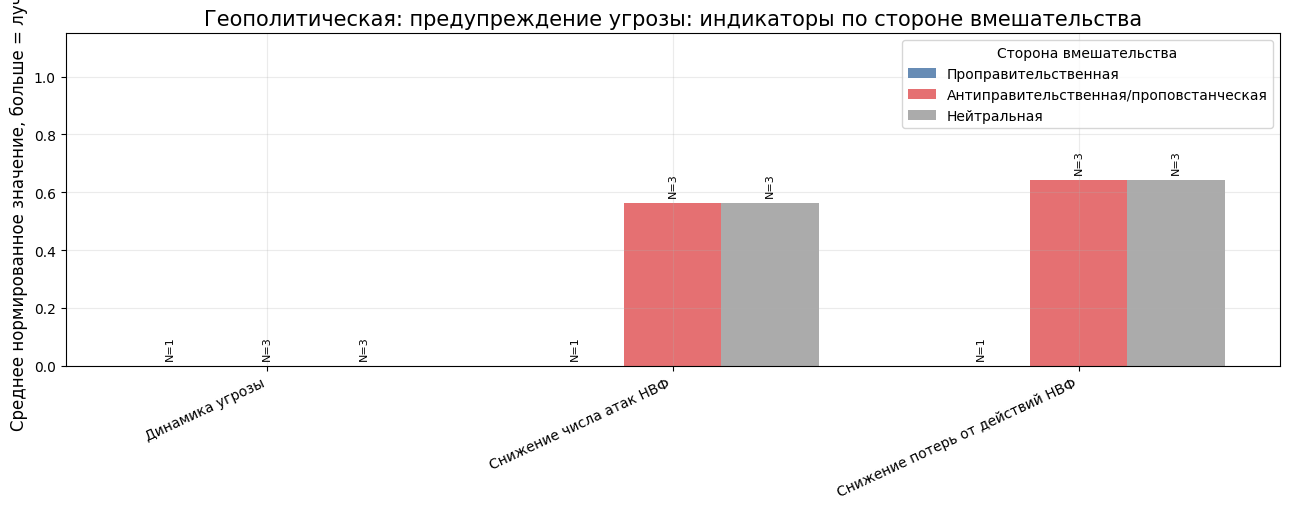

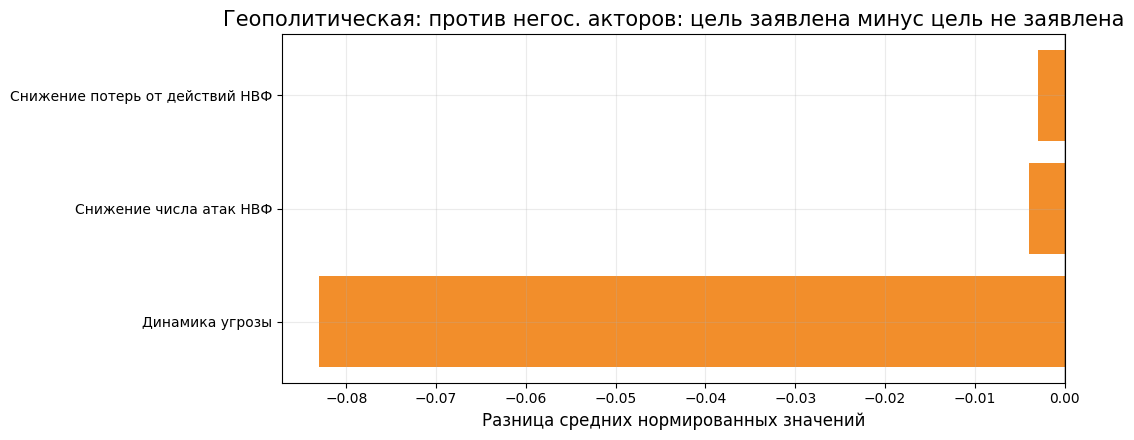

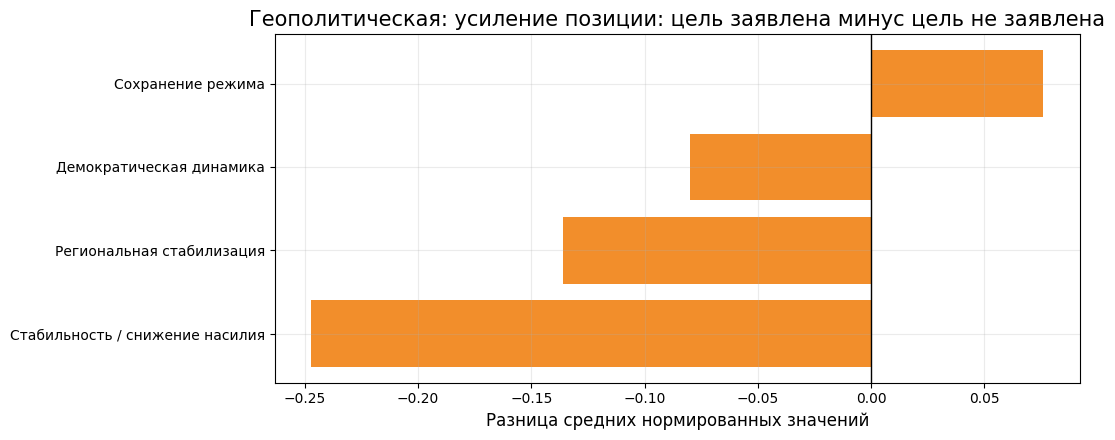

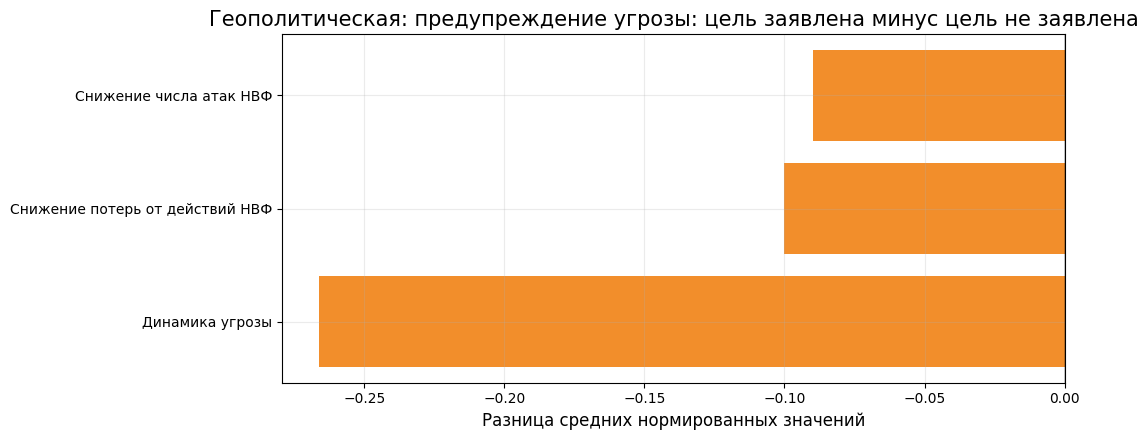

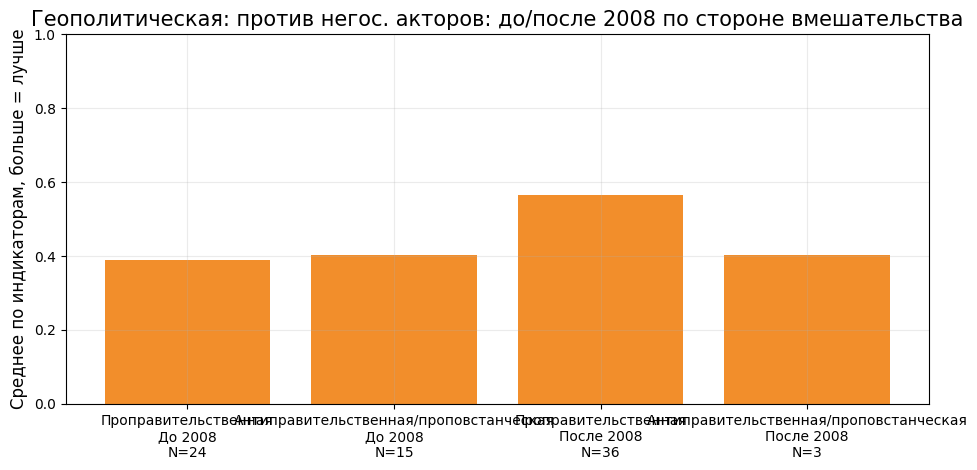

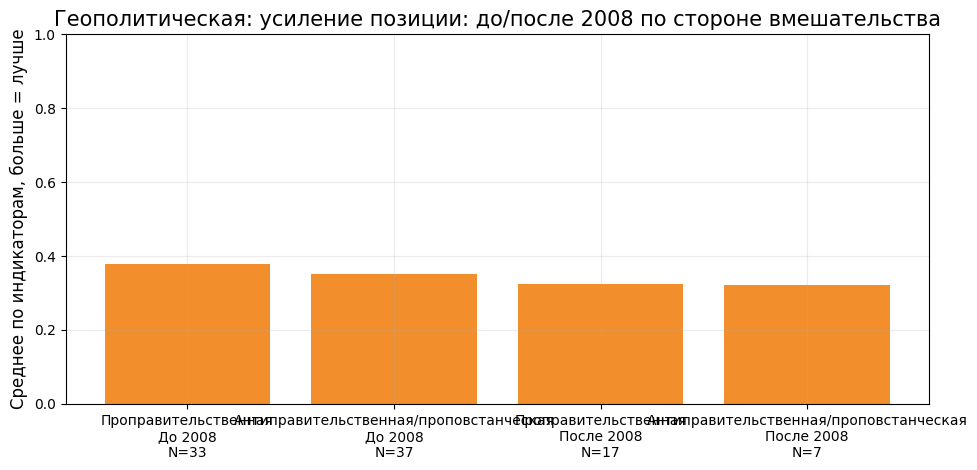

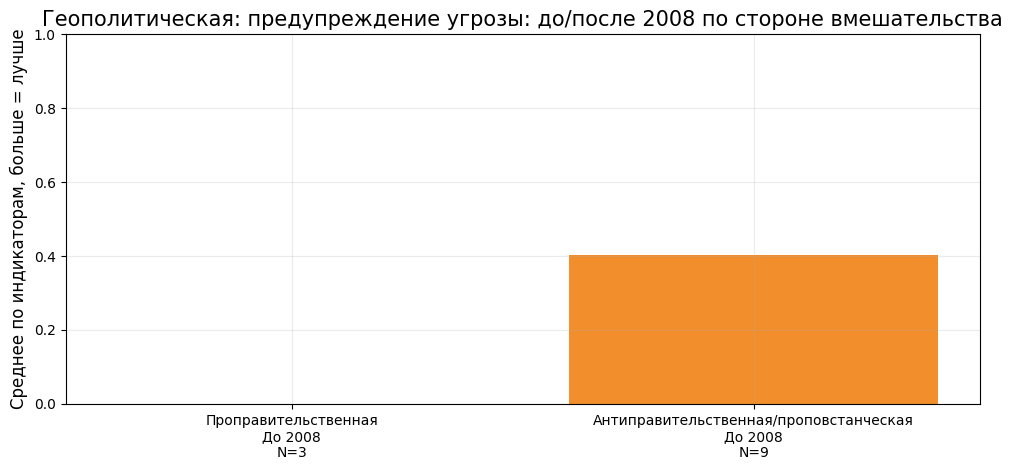

In [30]:
def normalize_direct(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return s
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mn == mx:
        return pd.Series(np.nan, index=s.index)
    if mn >= 0 and mx <= 1:
        return s
    if mn >= 1 and mx <= 5:
        return (s - 1) / 4
    return (s - mn) / (mx - mn)


def normalize_inverse_delta(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().empty:
        return s
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mn == mx:
        return pd.Series(np.nan, index=s.index)
    return 1 - ((s - mn) / (mx - mn))


def indicator_values(name):
    if name == "nonstate_attacks_reduction":
        raw = pd.to_numeric(df["nonstate_attacks_t1"], errors="coerce")
        return raw, normalize_inverse_delta(raw), "nonstate_attacks_t1"
    if name == "nonstate_casualties_reduction":
        raw = pd.to_numeric(df["nonstate_combatant_casualties_t1"], errors="coerce")
        return raw, normalize_inverse_delta(raw), "nonstate_combatant_casualties_t1"
    raw = pd.to_numeric(df[name], errors="coerce")
    return raw, normalize_direct(raw), name

geo_indicator_specs = {
    "geopolitical_counternonstate": [
        ("geo_threat_t3", "Динамика угрозы", "Угроза"),
        ("nonstate_attacks_reduction", "Снижение числа атак НВФ", "Насилие"),
        ("nonstate_casualties_reduction", "Снижение потерь от действий НВФ", "Насилие"),
    ],
    "geopolitical_position": [
        ("pol_regime_survival_t3", "Сохранение режима", "Политическая устойчивость"),
        ("pol_stability_t3", "Стабильность / снижение насилия", "Политическая устойчивость"),
        ("pol_stabilization_t3", "Региональная стабилизация", "Стабилизация"),
        ("pol_democracy_change_t3", "Демократическая динамика", "Дополнительный outcome"),
    ],
    "geopolitical_preemption": [
        ("geo_threat_t3", "Динамика угрозы", "Угроза"),
        ("nonstate_attacks_reduction", "Снижение числа атак НВФ", "Насилие"),
        ("nonstate_casualties_reduction", "Снижение потерь от действий НВФ", "Насилие"),
    ],
}

geo_case_rows = []
for goal, indicators in geo_indicator_specs.items():
    if goal not in df.columns:
        continue
    for indicator, indicator_ru, dimension in indicators:
        try:
            raw, value_norm, raw_variable = indicator_values(indicator)
        except KeyError:
            continue
        temp = pd.DataFrame({
            "i_dyad_id": df["i_dyad_id"],
            "goal": goal,
            "goal_ru": ru_goal(goal),
            "goal_declared": df[goal],
            "goal_declared_ru": np.where(df[goal].eq(1), "цель заявлена", "цель не заявлена"),
            "indicator": indicator,
            "indicator_ru": indicator_ru,
            "dimension": dimension,
            "raw_variable": raw_variable,
            "raw_value": raw,
            "value_norm": value_norm,
            "geo_score_t3": df["geo_score_t3"],
            "intervention_side_final": df["intervention_side_final"],
            "intervention_side_ru": df["intervention_side_ru"],
            "period_2008": df["period_2008"],
        })
        geo_case_rows.append(temp)

geo_indicator_case_df = pd.concat(geo_case_rows, ignore_index=True)

geo_indicator_summary_df = (
    geo_indicator_case_df[geo_indicator_case_df["goal_declared"].eq(1)]
    .groupby(["goal", "goal_ru", "indicator", "indicator_ru", "dimension", "raw_variable"], as_index=False)
    .agg(
        N=("value_norm", "count"),
        mean_normalized=("value_norm", "mean"),
        median_normalized=("value_norm", "median"),
        raw_mean=("raw_value", "mean"),
        geo_score_mean=("geo_score_t3", "mean"),
    )
    .round(3)
)

geo_goal_contrast_df = (
    geo_indicator_case_df
    .groupby(["goal", "goal_ru", "indicator", "indicator_ru", "goal_declared_ru"], as_index=False)
    .agg(N=("value_norm", "count"), mean_normalized=("value_norm", "mean"), raw_mean=("raw_value", "mean"))
    .round(3)
)

geo_goal_difference_df = (
    geo_goal_contrast_df.pivot_table(
        index=["goal", "goal_ru", "indicator", "indicator_ru"],
        columns="goal_declared_ru",
        values="mean_normalized"
    )
    .reset_index()
)
if {"цель заявлена", "цель не заявлена"}.issubset(geo_goal_difference_df.columns):
    geo_goal_difference_df["difference_declared_minus_not"] = (
        geo_goal_difference_df["цель заявлена"] - geo_goal_difference_df["цель не заявлена"]
    ).round(3)

geo_side_indicator_summary_df = (
    geo_indicator_case_df[geo_indicator_case_df["goal_declared"].eq(1)]
    .groupby(["goal", "goal_ru", "indicator", "indicator_ru", "intervention_side_final", "intervention_side_ru"], as_index=False)
    .agg(N=("value_norm", "count"), mean_normalized=("value_norm", "mean"), raw_mean=("raw_value", "mean"))
    .round(3)
)

geo_period_side_decomposition_df = (
    geo_indicator_case_df[
        geo_indicator_case_df["goal_declared"].eq(1)
        & geo_indicator_case_df["intervention_side_final"].isin(["pro_government", "pro_rebel"])
    ]
    .groupby(["goal", "goal_ru", "period_2008", "intervention_side_final", "intervention_side_ru"], as_index=False)
    .agg(N=("value_norm", "count"), mean_normalized=("value_norm", "mean"), geo_score_mean=("geo_score_t3", "mean"))
    .round(3)
)

strength_rows = []
for goal, subset in geo_indicator_summary_df.groupby("goal"):
    subset = subset.dropna(subset=["mean_normalized"]).sort_values("mean_normalized")
    if subset.empty:
        continue
    weakest = subset.iloc[0]
    strongest = subset.iloc[-1]
    strength_rows.append({
        "goal": goal,
        "goal_ru": weakest["goal_ru"],
        "weakest_indicator": weakest["indicator_ru"],
        "weakest_mean": weakest["mean_normalized"],
        "strongest_indicator": strongest["indicator_ru"],
        "strongest_mean": strongest["mean_normalized"],
    })
geo_indicator_strength_df = pd.DataFrame(strength_rows)

display(geo_indicator_summary_df)
display(geo_goal_contrast_df)
display(geo_indicator_strength_df)

heat = geo_indicator_summary_df.pivot(index="goal_ru", columns="indicator_ru", values="mean_normalized")
heat_n = geo_indicator_summary_df.pivot(index="goal_ru", columns="indicator_ru", values="N")
fig, ax = plt.subplots(figsize=(14, 4.8))
im = ax.imshow(heat.values, aspect="auto", vmin=0, vmax=1, cmap="YlOrBr")
ax.set_xticks(range(heat.shape[1]), heat.columns, rotation=35, ha="right")
ax.set_yticks(range(heat.shape[0]), heat.index)
ax.set_title("Декомпозиция геополитической результативности по индикаторам")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        n = heat_n.iloc[i, j]
        ax.text(j, i, "" if pd.isna(val) else f"{val:.2f}\nN={int(n)}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Среднее нормированное значение, больше = лучше")
plt.tight_layout()
save_current_figure("figure_04")
plt.show()

for goal in geopolitical_goal_cols:
    plot_df = geo_indicator_summary_df[geo_indicator_summary_df["goal"].eq(goal)].sort_values("mean_normalized")
    if plot_df.empty:
        continue
    labels = plot_df["indicator_ru"] + "\nN=" + plot_df["N"].astype(int).astype(str)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.barh(labels, plot_df["mean_normalized"], color=BLOCK_COLORS["geopolitical"])
    ax.set_xlim(0, 1)
    ax.set_title(f"{ru_goal(goal)}: вклад отдельных индикаторов")
    ax.set_xlabel("Среднее нормированное значение, больше = лучше")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_05")
    plt.show()

side_order = ["pro_government", "pro_rebel", "neutral"]
for goal in geopolitical_goal_cols:
    plot_df = geo_side_indicator_summary_df[geo_side_indicator_summary_df["goal"].eq(goal)].copy()
    if plot_df.empty:
        continue
    indicators = plot_df["indicator_ru"].drop_duplicates().tolist()
    x = np.arange(len(indicators))
    width = 0.24
    fig, ax = plt.subplots(figsize=(13, 5.2))
    for idx, side in enumerate(side_order):
        side_df = plot_df[plot_df["intervention_side_final"].eq(side)].set_index("indicator_ru")
        values = [side_df.loc[ind, "mean_normalized"] if ind in side_df.index else np.nan for ind in indicators]
        ns = [side_df.loc[ind, "N"] if ind in side_df.index else np.nan for ind in indicators]
        offset = (idx - 1) * width
        bars = ax.bar(x + offset, values, width=width, label=SIDE_RU.get(side, side), color=SIDE_COLORS.get(side, BLOCK_COLORS["other"]), alpha=0.85)
        for bar, n in zip(bars, ns):
            if pd.notna(n) and pd.notna(bar.get_height()):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"N={int(n)}", ha="center", va="bottom", fontsize=8, rotation=90)
    ax.set_xticks(x, indicators, rotation=25, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{ru_goal(goal)}: индикаторы по стороне вмешательства")
    ax.set_ylabel("Среднее нормированное значение, больше = лучше")
    ax.legend(title="Сторона вмешательства")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_06")
    plt.show()

for goal in geopolitical_goal_cols:
    plot_df = geo_goal_difference_df[geo_goal_difference_df["goal"].eq(goal)].dropna(subset=["difference_declared_minus_not"]).sort_values("difference_declared_minus_not")
    if plot_df.empty:
        continue
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.barh(plot_df["indicator_ru"], plot_df["difference_declared_minus_not"], color=BLOCK_COLORS["geopolitical"])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{ru_goal(goal)}: цель заявлена минус цель не заявлена")
    ax.set_xlabel("Разница средних нормированных значений")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_07")
    plt.show()

hist_plot = geo_period_side_decomposition_df.copy()
hist_plot["group"] = hist_plot["intervention_side_ru"] + "\n" + hist_plot["period_2008"]
for goal in geopolitical_goal_cols:
    plot_df = hist_plot[hist_plot["goal"].eq(goal)].copy()
    if plot_df.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 4.8))
    labels = plot_df["group"] + "\nN=" + plot_df["N"].astype(int).astype(str)
    ax.bar(labels, plot_df["mean_normalized"], color=BLOCK_COLORS["geopolitical"])
    ax.set_ylim(0, 1)
    ax.set_title(f"{ru_goal(goal)}: до/после 2008 по стороне вмешательства")
    ax.set_ylabel("Среднее по индикаторам, больше = лучше")
    ax.tick_params(axis="x", labelrotation=0)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    save_current_figure("figure_08")
    plt.show()


## 11. Исторические периоды до/после 2008 года

Сравнение периодов проводится отдельно для проправительственных и антиправительственных интервенций.


In [31]:
historical_scores = [c for c in ["overall_score", "geo_score_t3", "hum_score_t2", "pol_score_t3"] if c in df.columns]
side_period_focus = df[df["intervention_side_final"].isin(["pro_government", "pro_rebel"])].copy()
side_period_focus["side_period_group"] = side_period_focus["intervention_side_ru"] + " / " + side_period_focus["period_2008"]

historical_side_period_scores_df = (
    side_period_focus.groupby(["intervention_side_final", "intervention_side_ru", "period_2008", "side_period_group"], as_index=False)
    .agg(
        N=("overall_score", "count"),
        **{f"mean_{score}": (score, "mean") for score in historical_scores}
    )
    .round(3)
)

historical_side_period_long_df = historical_side_period_scores_df.melt(
    id_vars=["intervention_side_final", "intervention_side_ru", "period_2008", "side_period_group", "N"],
    value_vars=[f"mean_{score}" for score in historical_scores],
    var_name="score",
    value_name="mean"
)
historical_side_period_long_df["score"] = historical_side_period_long_df["score"].str.replace("mean_", "", regex=False)
historical_side_period_long_df["score_ru"] = historical_side_period_long_df["score"].map(SCORE_RU)

period_tests = []
for score in historical_scores:
    for side, subset in side_period_focus.groupby("intervention_side_final"):
        before = subset.loc[subset["period_2008"].eq("До 2008"), score].dropna()
        after = subset.loc[subset["period_2008"].eq("После 2008"), score].dropna()
        if len(before) >= 3 and len(after) >= 3:
            stat, p = mannwhitneyu(before, after, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan
        period_tests.append({
            "intervention_side_final": side,
            "intervention_side_ru": SIDE_RU.get(side, side),
            "score": score,
            "score_ru": SCORE_RU.get(score, score),
            "N_before_2008": len(before),
            "mean_before_2008": round(before.mean(), 3) if len(before) else np.nan,
            "N_after_2008": len(after),
            "mean_after_2008": round(after.mean(), 3) if len(after) else np.nan,
            "difference_after_minus_before": round(after.mean() - before.mean(), 3) if len(before) and len(after) else np.nan,
            "p_value_mannwhitney": round(p, 4) if pd.notna(p) else np.nan,
        })
period_tests_df = pd.DataFrame(period_tests)

display(historical_side_period_scores_df)
display(period_tests_df)


,intervention_side_final,intervention_side_ru,period_2008,side_period_group,N,mean_overall_score,mean_geo_score_t3,mean_hum_score_t2,mean_pol_score_t3
0,pro_government,Проправительственная,До 2008,Проправительственная / До 2008,26,3.019,2.385,3.077,1.269
1,pro_government,Проправительственная,После 2008,Проправительственная / После 2008,23,2.761,2.522,2.609,0.804
2,pro_rebel,Антиправительственная/проповстанческая,До 2008,Антиправительственная/проповстанческая / До 2008,16,2.688,2.250,2.875,0.812
3,pro_rebel,Антиправительственная/проповстанческая,После 2008,Антиправительственная/проповстанческая / После...,5,2.900,2.000,3.000,0.400


,intervention_side_final,intervention_side_ru,score,score_ru,N_before_2008,mean_before_2008,N_after_2008,mean_after_2008,difference_after_minus_before,p_value_mannwhitney
0,pro_government,Проправительственная,overall_score,Общая результативность,26,3.019,23,2.761,-0.258,0.2355
1,pro_rebel,Антиправительственная/проповстанческая,overall_score,Общая результативность,16,2.688,5,2.900,0.212,0.8553
2,pro_government,Проправительственная,geo_score_t3,Геополитическая результативность,26,2.385,23,2.522,0.137,0.4670
3,pro_rebel,Антиправительственная/проповстанческая,geo_score_t3,Геополитическая результативность,16,2.250,5,2.000,-0.250,0.4654
4,pro_government,Проправительственная,hum_score_t2,Гуманитарная результативность,26,3.077,23,2.609,-0.468,0.0263
5,pro_rebel,Антиправительственная/проповстанческая,hum_score_t2,Гуманитарная результативность,16,2.875,5,3.000,0.125,0.8926
6,pro_government,Проправительственная,pol_score_t3,Политическая результативность,26,1.269,23,0.804,-0.465,0.0811
7,pro_rebel,Антиправительственная/проповстанческая,pol_score_t3,Политическая результативность,16,0.812,5,0.400,-0.412,0.3368


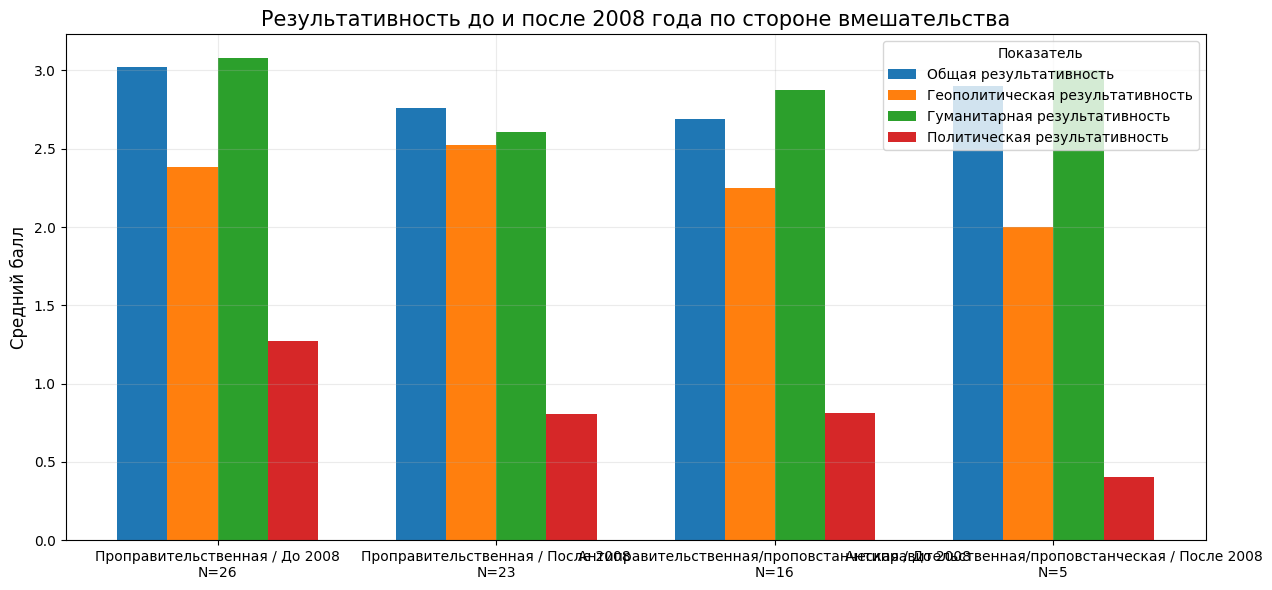

In [32]:
score_order = [SCORE_RU[s] for s in historical_scores]
plot_df = historical_side_period_long_df.copy()
groups = historical_side_period_scores_df["side_period_group"].tolist()
x = np.arange(len(groups))
width = 0.18
fig, ax = plt.subplots(figsize=(13, 6))
for idx, score in enumerate(historical_scores):
    values = []
    for group in groups:
        match = plot_df[(plot_df["side_period_group"].eq(group)) & (plot_df["score"].eq(score))]
        values.append(match["mean"].iloc[0] if len(match) else np.nan)
    ax.bar(x + (idx - (len(historical_scores)-1)/2) * width, values, width=width, label=SCORE_RU[score])
ax.set_xticks(x, [f"{g}\nN={int(historical_side_period_scores_df.loc[historical_side_period_scores_df['side_period_group'].eq(g), 'N'].iloc[0])}" for g in groups], rotation=0)
ax.set_title("Результативность до и после 2008 года по стороне вмешательства")
ax.set_ylabel("Средний балл")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Показатель")
plt.tight_layout()
save_current_figure("figure_23")
plt.show()


## 12. Регрессионные модели

Оставлены OLS-модели, ANOVA для базовой OLS и ordinal logit для порядковой шкалы общей результативности.


In [33]:
level3_predictors = ["delay_months", "duration_years", "duration_sq"] + [v for v in support_vars if df[v].notna().sum() >= 10]
level3_rhs = " + ".join(level3_predictors)

model_level3_full = smf.ols(f"overall_score ~ {level3_rhs}", data=df).fit()
model_level3_mil = smf.ols(f"mil_score_t1 ~ {level3_rhs}", data=df).fit()
model_level3_hum = smf.ols(f"hum_score_t2 ~ {level3_rhs}", data=df).fit()
model_level3_geo = smf.ols(f"geo_score_t3 ~ {level3_rhs}", data=df).fit()

level3_models = pd.concat([
    model_table(model_level3_full, "overall_full_support"),
    model_table(model_level3_mil, "mil_full_support"),
    model_table(model_level3_hum, "hum_full_support"),
    model_table(model_level3_geo, "geo_full_support"),
], ignore_index=True)

level3_models


model_base_cols = [
    "overall_score", "intervention_side_final",
    "military_goal", "humanitarian_goal", "geopolitical_goal",
    "subjective_hum_crisis", "objective_hum_crisis",
] + support_vars
regression_referent_col = referent_col if "referent_col" in globals() and referent_col in df.columns else ("refsubject_ru_clean" if "refsubject_ru_clean" in df.columns else None)
regression_extra_cols = [regression_referent_col] if regression_referent_col else []
regression_df = df[model_base_cols + regression_extra_cols].copy()
for col in ["overall_score", "military_goal", "humanitarian_goal", "geopolitical_goal", "subjective_hum_crisis", "objective_hum_crisis"] + support_vars:
    regression_df[col] = pd.to_numeric(regression_df[col], errors="coerce")

if regression_referent_col and regression_referent_col in regression_df.columns:
    ref_counts = regression_df[regression_referent_col].value_counts(dropna=True)
    top_refsubjects = ref_counts[ref_counts >= 3].index.tolist()[:6]
    regression_df["refsubject_model_group"] = np.where(regression_df[regression_referent_col].isin(top_refsubjects), regression_df[regression_referent_col], "other")
else:
    regression_df["refsubject_model_group"] = "not_available"

ols_base_formula = "overall_score ~ C(intervention_side_final) + military_goal + humanitarian_goal + geopolitical_goal + subjective_hum_crisis + objective_hum_crisis"
ols_support_formula = ols_base_formula + " + " + " + ".join(support_vars)
include_refsubject = regression_df["refsubject_model_group"].nunique(dropna=True) > 2 and regression_df.groupby("refsubject_model_group")["overall_score"].count().min() >= 3
ols_ref_formula = ols_support_formula + (" + C(refsubject_model_group)" if include_refsubject else "")

ols_models = []
model_errors = []
for name, formula in [
    ("OLS_base", ols_base_formula),
    ("OLS_support", ols_support_formula),
    ("OLS_support_refsubject", ols_ref_formula),
]:
    try:
        model = smf.ols(formula, data=regression_df).fit()
        ols_models.append((name, model, formula))
    except Exception as e:
        model_errors.append({"model": name, "error": str(e)})

regression_coefficients_df = pd.concat([model_table(model, name) for name, model, _ in ols_models], ignore_index=True) if ols_models else pd.DataFrame()
regression_model_compare_df = pd.DataFrame([
    {"model": name, "type": "OLS", "nobs": int(model.nobs), "aic": round(model.aic, 3), "bic": round(model.bic, 3), "formula": formula}
    for name, model, formula in ols_models
])

try:
    ols_anova_table = sm.stats.anova_lm(ols_models[0][1], typ=2).reset_index().rename(columns={"index": "term"}) if ols_models else pd.DataFrame()
except Exception as e:
    ols_anova_table = pd.DataFrame([{"message": f"ANOVA не рассчитана: {e}"}])

ordinal_result = None
ordinal_coefficients_df = pd.DataFrame()
ordinal_status = "OrderedModel недоступна" if OrderedModel is None else ""
ordinal_cols = [
    "overall_score", "intervention_side_final", "military_goal", "humanitarian_goal", "geopolitical_goal",
    "subjective_hum_crisis", "objective_hum_crisis",
] + support_vars
ordinal_df = regression_df[ordinal_cols].dropna().copy()
if OrderedModel is not None and len(ordinal_df) >= 30 and ordinal_df["overall_score"].nunique() >= 3:
    try:
        y = ordinal_df["overall_score"].round().astype(int)
        X = pd.get_dummies(ordinal_df.drop(columns=["overall_score"]), columns=["intervention_side_final"], drop_first=True, dtype=float)
        ordinal_model = OrderedModel(y, X, distr="logit")
        ordinal_result = ordinal_model.fit(method="bfgs", disp=False)
        ordinal_coefficients_df = pd.DataFrame({
            "model": "ordinal_logit",
            "variable": ordinal_result.params.index,
            "coef": ordinal_result.params.values,
            "p_value": ordinal_result.pvalues.values,
            "odds_ratio": np.exp(ordinal_result.params.values),
        }).round({"coef": 4, "p_value": 4, "odds_ratio": 3})
        regression_model_compare_df = pd.concat([
            regression_model_compare_df,
            pd.DataFrame([{
                "model": "ordinal_logit",
                "type": "Ordinal logit",
                "nobs": int(ordinal_result.nobs),
                "aic": round(ordinal_result.aic, 3),
                "bic": round(ordinal_result.bic, 3),
                "formula": "overall_score ordered ~ side + goal blocks + crisis + " + " + ".join(support_vars),
            }])
        ], ignore_index=True)
        regression_coefficients_df = pd.concat([regression_coefficients_df, ordinal_coefficients_df], ignore_index=True)
    except Exception as e:
        ordinal_status = f"Ordinal regression не построена: {e}"
else:
    ordinal_status = ordinal_status or f"Ordinal regression не построена: N={len(ordinal_df)}, категорий overall={ordinal_df['overall_score'].nunique() if len(ordinal_df) else 0}"

display(regression_model_compare_df)
display(regression_coefficients_df)
display(ols_anova_table)

model_sample_sizes = pd.DataFrame({
    "model": ["H3", "H4_hum", "H4_mil", "Full_overall", "Geo_full"],
    "n": [
        int(model_h3.nobs),
        int(model_h4_hum.nobs),
        int(model_h4_mil.nobs),
        int(model_level3_full.nobs),
        int(model_level3_geo.nobs),
    ]
})

duration_description = df["duration_years"].describe().to_frame("duration_years")

model_sample_sizes, duration_description


,model,type,nobs,aic,bic,formula
0,OLS_base,OLS,98,240.903,261.583,overall_score ~ C(intervention_side_final) + m...
1,OLS_support,OLS,90,227.814,255.312,overall_score ~ C(intervention_side_final) + m...
2,OLS_support_refsubject,OLS,90,224.691,267.188,overall_score ~ C(intervention_side_final) + m...
3,ordinal_logit,Ordinal logit,90,204.281,236.779,overall_score ordered ~ side + goal blocks + c...


,model,variable,coef,p_value,odds_ratio
0,OLS_base,Intercept,3.1395,0.0000,NaN
1,OLS_base,C(intervention_side_final)[T.pro_government],0.0686,0.7259,NaN
2,OLS_base,C(intervention_side_final)[T.pro_rebel],-0.0401,0.8696,NaN
3,OLS_base,military_goal,-0.2263,0.2684,NaN
4,OLS_base,humanitarian_goal,0.3363,0.1372,NaN
5,OLS_base,geopolitical_goal,-0.3828,0.0445,NaN
6,OLS_base,subjective_hum_crisis,-0.4553,0.0086,NaN
7,OLS_base,objective_hum_crisis,0.0799,0.6528,NaN
8,OLS_support,Intercept,3.2995,0.0000,NaN
9,OLS_support,C(intervention_side_final)[T.pro_government],-0.0062,0.9768,NaN


,term,sum_sq,df,F,PR(>F)
0,C(intervention_side_final),0.180274,2.0,0.142468,0.867410
1,military_goal,0.784562,1.0,1.240063,0.268424
2,humanitarian_goal,1.422865,1.0,2.248953,0.137205
3,geopolitical_goal,2.627478,1.0,4.152941,0.044498
4,subjective_hum_crisis,4.561846,1.0,7.210366,0.008630
5,objective_hum_crisis,0.128892,1.0,0.203723,0.652818
6,Residual,56.941096,90.0,NaN,NaN


(          model   n
 0            H3  88
 1        H4_hum  93
 2        H4_mil  89
 3  Full_overall  82
 4      Geo_full  82,
        duration_years
 count       88.000000
 mean         2.167614
 std          4.029019
 min          0.000000
 25%          0.083333
 50%          0.583333
 75%          2.020833
 max         19.833333)

## 13. Итоговые таблицы и графики

Финальные таблицы сохраняются в `outputs/tables`, а графики — в `outputs/figures`.


In [34]:
FINAL_TABLES = {
    "balance_side": balance_side_df,
    "balance_goal_type": balance_goal_type_df,
    "balance_goals": balance_goals_df,
    "balance_period_2008": period_2008_balance_df,
    "h1_side_summary": h1_side_summary_df,
    "h1_side_difference": h1_side_diff_df,
    "h1_side_correlations": h1_corr_df,
    "h1_directional_goals": h1_military_directional_goals_df,
    "level1_specific_goals": specific_goal_df,
    "level1_cross_effects": cross_df,
    "level2_empty_promises": empty_df,
    "level2_latent_success": latent_df,
    "level2_latent_by_side": h2_latent_by_side_df,
    "level2_declared_vs_absent": h2_declared_vs_absent_df,
    "referent_summary": referent_summary_df,
    "referent_tests": referent_tests_df,
    "referent_side_summary": ref_side_summary_df,
    "level3_delay_correlations": delay_corr_df,
    "level3_duration_model": h3_table,
    "support_score_correlations": support_score_correlations_df,
    "support_goal_correlations": support_goal_correlations_df,
    "support_correlations_by_side": support_correlations_by_side_df,
    "attention_context_correlations": attention_context_corr_df,
    "attention_models": attention_level3_models,
    "law_correlations": law_corr_df,
    "geo_indicator_summary": geo_indicator_summary_df,
    "geo_goal_contrast": geo_goal_contrast_df,
    "geo_indicator_strength": geo_indicator_strength_df,
    "geo_side_indicator_summary": geo_side_indicator_summary_df,
    "historical_side_period_scores": historical_side_period_scores_df,
    "historical_period_tests": period_tests_df,
    "regression_model_compare": regression_model_compare_df,
    "regression_coefficients": regression_coefficients_df,
    "regression_anova": ols_anova_table,
}

saved_tables = []
for name, table in FINAL_TABLES.items():
    if isinstance(table, pd.DataFrame) and not table.empty:
        saved_tables.append({"table": name, "path": str(save_table(table, name).relative_to(ROOT))})

saved_tables_df = pd.DataFrame(saved_tables)
display(saved_tables_df)


,table,path
0,balance_side,outputs/tables/balance_side.csv
1,balance_goal_type,outputs/tables/balance_goal_type.csv
2,balance_goals,outputs/tables/balance_goals.csv
3,balance_period_2008,outputs/tables/balance_period_2008.csv
4,h1_side_summary,outputs/tables/h1_side_summary.csv
5,h1_side_difference,outputs/tables/h1_side_difference.csv
6,h1_side_correlations,outputs/tables/h1_side_correlations.csv
7,h1_directional_goals,outputs/tables/h1_directional_goals.csv
8,level1_specific_goals,outputs/tables/level1_specific_goals.csv
9,level1_cross_effects,outputs/tables/level1_cross_effects.csv
